In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tabix
import gzip
import pysam
# import vcf

In [2]:

def plot_isoform_annotations(annotation_exons, gene, colores=None, start=None, end=None, 
                             figsize=None, lwidth=5, iso_order=None, axes=None, xlim=None):

    gene_exons = annotation_exons.loc[annotation_exons.gene_id == gene]

    if iso_order is None:
        isoforms = sorted(gene_exons.transcript_id.unique())
    else:
        isoforms = iso_order

    isoform_dict = {}
    for i, iso in enumerate(isoforms):
        isoform_name = f'isoform_{str(i+1)}'
        df = gene_exons.loc[gene_exons.transcript_id == iso].copy()
        df['transcript_id'] =  f'{gene}.{isoform_name}'
        isoform_dict.update({isoform_name:{'df':df}})

    try:
        chrom = list(annotation_exons.chrom)[0]
    except:
        chrom = list(annotation_exons['#chrom'])[0]
    if start is None:
        start = str(np.min([int(list(gene_exons.start)[0]), int(list(gene_exons.start)[0])]) - 1000)
    if end is None:
        end = str(np.max([int(list(gene_exons.end)[-1]), int(list(gene_exons.end)[-1])]) + 1000)

    coords = [f'{chrom}:{start}', f'{chrom}:{end}']

    # print(isoform_dict)

    plot_gene_isoforms(isoform_dict, coords, color_list = colores, figsize=figsize, lwidth=lwidth, axes=axes, xlim=xlim)


def plot_gene_isoforms(isoforms_dict, coordinates, color_list = None, axes=None, figsize=None, lwidth=5, xlim=None):


    if xlim is None:
        xlim1 = int(coordinates[0].split(':')[1])
        xlim2 = int(coordinates[-1].split(':')[1])
#         print(xlim)
    else:
        xlim1 = xlim[0]
        xlim2 = xlim[1]
    

    if color_list is None:
        color_list = sns.color_palette("tab10")

    K = len(isoforms_dict)

    if figsize is None:
        figsize=(20, 3)

    if axes is None:
        fig, axes = plt.subplots(K, 1, figsize=figsize)

    for i in range(K):
        isoform_df = isoforms_dict[f'isoform_{str(i+1)}']['df']
        # print(isoform_df)
        ax = axes[i]
        color = color_list[i]
        plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth=lwidth)


def plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth):
    # print(isoform_df)
    is_first = True
    for idx, row in isoform_df.iterrows():
        start = int(row.start)
        end = int(row.end)
        if is_first:
            first = end
            is_first = False
    
        ax.fill_between([start, end], [0, 0], [1, 1], color = color, zorder=2)
    
    ax.plot([first, start], [0.5, 0.5], c=color, linewidth=lwidth)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['bottom', 'top', 'right', 'left']].set_visible(False)
    ax.set_xlim([xlim1, xlim2])

    # print(xlim1, xlim2)


In [3]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr11.txt.tabix.gz')

# Define a function to read the content
def run_tabix(tabix_file, chrom, start, end, file_type = 'other'):
    tabix_obj = tabix.open(tabix_file)
    # Fetch data from the tabix file in the desired range
    result = tabix_obj.query(chrom, start, end)
    
    rows = [line for line in result]
    
    with gzip.open(tabix_file) as fh:
        cols = fh.readline().decode().rstrip().split('\t')
    
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    if file_type == 'leafcutter':
        df['gid'] = df.pid.apply(lambda x: x.split(':')[3])
    elif file_type == 'expression':
        df['gid'] = df.pid.apply(lambda x: x.split('.')[0])
        
    return df


In [4]:
nom_df = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/up_results.tsv.gz', sep='\t')

In [5]:
best_df = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'UP') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta <= -0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta >= 0.01)))]
best_df2 = nom_df.loc[(nom_df.distance <= 3000) & (nom_df.itype == 'PR') & (((nom_df.sQTL_beta >= 0.01) & (nom_df.eQTL_beta >= 0.01)) | ((nom_df.sQTL_beta <= -0.01) & (nom_df.eQTL_beta <= -0.01)))]
best_df.loc[best_df.gene == 'ENSG00000100412']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,0.000005,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [6]:
best_df.loc[(best_df.sQTL_pval <= 1e-5) & (best_df.eQTL_pval <= 1e-5)].loc[222]#.intron

intron          chr11:802376:802542:clu_21995_-:UP:chr11_80301...
gene                                              ENSG00000177595
var_id                                       chr11_803017_A_G_b38
distance                                                      475
distance_abs                                                  475
sQTL_beta                                               -0.302786
sQTL_pval                                                0.000006
eQTL_beta                                                0.184477
eQTL_pval                                                0.000009
cluster                                               clu_21995_-
itype                                                          UP
tissue                                                  Pituitary
PSI                                                      0.094601
chrom                                                       chr11
start                                                      802376
end       

In [7]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

In [8]:
annot.loc[(annot.gene_id == 'ENSG00000177595') & ((annot.end.astype(int) - 802376).abs() <= 2)]

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
351,chr11,802323,802376,ENSG00000177595,PIDD1,-,protein_coding,ENST00000528122,protein_coding_CDS_not_defined


In [9]:
annot.loc[annot.transcript_id=='ENST00000528122']

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
351,chr11,802323,802376,ENSG00000177595,PIDD1,-,protein_coding,ENST00000528122,protein_coding_CDS_not_defined
353,chr11,802543,802597,ENSG00000177595,PIDD1,-,protein_coding,ENST00000528122,protein_coding_CDS_not_defined
363,chr11,802682,803149,ENSG00000177595,PIDD1,-,protein_coding,ENST00000528122,protein_coding_CDS_not_defined


In [10]:
qqnorm.loc[qqnorm.gid == 'clu_21995_-']

,#Chr,start,end,pid,gid,strand,GTEX-1128S,GTEX-113JC,GTEX-117XS,GTEX-117YW,...,GTEX-Y111,GTEX-YFC4,GTEX-Z93S,GTEX-ZAB4,GTEX-ZAJG,GTEX-ZAK1,GTEX-ZDXO,GTEX-ZF28,GTEX-ZUA1,GTEX-ZYY3
233,chr11,1,821138,chr11:802396:802542:clu_21995_-:PR:chr11_32113...,clu_21995_-,-,-0.8027317799228704,0.7008912809156492,-0.9260008153401202,0.9165330508985147,...,-0.9045863728423845,0.3523418236798613,1.2427835095336408,-0.3162757237924231,-0.4358225087903581,0.8322254435318557,1.522712689770292,0.3877732709049057,0.24302214846111225,0.23334333857828607
242,chr11,1,821138,chr11:802376:802542:clu_21995_-:UP:chr11_32113...,clu_21995_-,-,0.9185236146225271,-0.5859718862122804,1.0299668570928793,-0.9013648070576962,...,1.0366525198654701,-0.12112411729749312,-1.3435169749557694,0.14554047017697996,0.6196007635829484,-0.7954671729012432,-1.7892485582150168,-0.5493122350570273,-0.018751941184840967,-0.05921407313963346
336,chr11,78759,1078759,chr11:802396:802542:clu_21995_-:PR:chr11_57875...,clu_21995_-,-,-0.8027317799228704,0.7008912809156492,-0.9260008153401202,0.9165330508985147,...,-0.9045863728423845,0.3523418236798613,1.2427835095336408,-0.3162757237924231,-0.4358225087903581,0.8322254435318557,1.522712689770292,0.3877732709049057,0.24302214846111225,0.23334333857828607
382,chr11,78759,1078759,chr11:802376:802542:clu_21995_-:UP:chr11_57875...,clu_21995_-,-,0.9185236146225271,-0.5859718862122804,1.0299668570928793,-0.9013648070576962,...,1.0366525198654701,-0.12112411729749312,-1.3435169749557694,0.14554047017697996,0.6196007635829484,-0.7954671729012432,-1.7892485582150168,-0.5493122350570273,-0.018751941184840967,-0.05921407313963346
628,chr11,303017,1303017,chr11:802376:802542:clu_21995_-:UP:chr11_80301...,clu_21995_-,-,0.9185236146225271,-0.5859718862122804,1.0299668570928793,-0.9013648070576962,...,1.0366525198654701,-0.12112411729749312,-1.3435169749557694,0.14554047017697996,0.6196007635829484,-0.7954671729012432,-1.7892485582150168,-0.5493122350570273,-0.018751941184840967,-0.05921407313963346
633,chr11,303017,1303017,chr11:802396:802542:clu_21995_-:PR:chr11_80301...,clu_21995_-,-,-0.8027317799228704,0.7008912809156492,-0.9260008153401202,0.9165330508985147,...,-0.9045863728423845,0.3523418236798613,1.2427835095336408,-0.3162757237924231,-0.4358225087903581,0.8322254435318557,1.522712689770292,0.3877732709049057,0.24302214846111225,0.23334333857828607


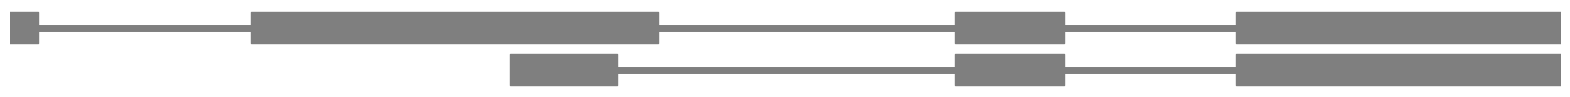

In [11]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000528122', 'ENST00000411829'])], 'ENSG00000177595', 
                         colores=['tab:gray']*3, start=802376-300, end=802542+300, figsize=(20, 1), lwidth=5, iso_order=None)

In [55]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['#Chr'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])

In [56]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['#phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]
snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))

In [57]:
LD = pd.read_csv('../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)


In [58]:
gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

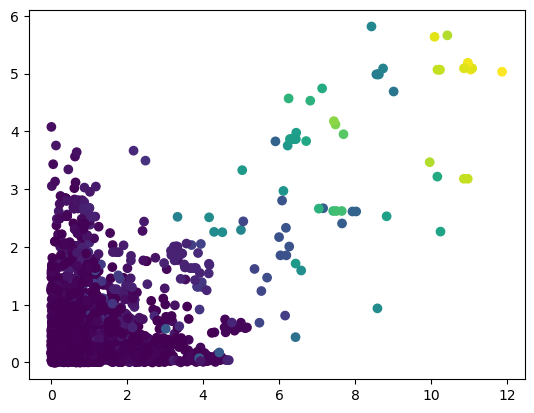

In [59]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
plt.scatter(x, y, c=r2)

In [25]:
def get_best_snp_record(vcf, snp):
    
    chrom, location = snp.split(':')
    location = int(location)
    
    record_list = []
    for record in vcf.fetch(chrom, location-1, location+1):  
        if record.POS == location:
#             print(chrom, location)
            return [record]
        record_list.append(record)
        
    return record_list


In [26]:
vcf_gtex = vcf.Reader(open("/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz", 'br'))

In [62]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

In [29]:
for r in records:
    break

In [27]:
   
def make_boxplot_df(qqnorm_data, phenotype, record, phenotype_class='', color_by_phenotype=False):
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    if color_by_phenotype:
        colores = [color_by_phenotype]*3

    else:
        colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.5, fliersize=0, 
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.5, edgecolor='tab:gray', facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    return ax

In [74]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

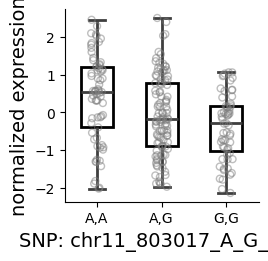

In [148]:
df = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

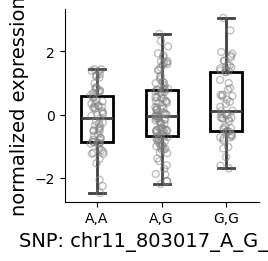

In [149]:
df = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])

In [6]:
best_df.loc[(best_df.sQTL_pval <= 1e-10) & (best_df.eQTL_pval <= 1e-6)].loc[168].intron

'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism'

In [7]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-30000, 614475+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_sp = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_sp_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

In [8]:
qqnorm_sp.loc[qqnorm_sp.pid.apply(lambda x: '614037:614475' in x) & (qqnorm_sp.pid.apply(lambda x: 'chr11_578759_N_N_Hypothyroidism' in x))]

,#Chr,start,end,pid,gid,strand,GTEX-111CU,GTEX-111FC,GTEX-1122O,GTEX-117YX,...,GTEX-ZP4G,GTEX-ZPCL,GTEX-ZPIC,GTEX-ZPU1,GTEX-ZTTD,GTEX-ZV6S,GTEX-ZVP2,GTEX-ZVZP,GTEX-ZYFG,GTEX-ZZPU
519,chr11,78759,1078759,chr11:614037:614475:clu_20133_-:UP:chr11_57875...,clu_20133_-,-,0.3458873621060413,1.8067043005687213,0.4790821131593002,0.9822032476287139,...,1.7648641639415632,0.7842227600650633,1.075638920050643,-0.13016728527956772,0.5505874917688159,-0.10724779243644036,-1.4287494461733503,0.1772058980117378,0.31211477173482727,0.8413904807731433


In [9]:
qqnorm_lcl.loc[qqnorm_lcl.pid.apply(lambda x: '614037:614475' in x) & (qqnorm_lcl.pid.apply(lambda x: 'chr11_578759_N_N_Hypothyroidism' in x))]

,#Chr,start,end,pid,gid,strand,GTEX-1122O,GTEX-11EM3,GTEX-11EMC,GTEX-11EQ9,...,GTEX-ZTPG,GTEX-ZTSS,GTEX-ZTTD,GTEX-ZTX8,GTEX-ZUA1,GTEX-ZV6S,GTEX-ZV7C,GTEX-ZVT2,GTEX-ZVZP,GTEX-ZXES
484,chr11,78759,1078759,chr11:614037:614475:clu_18165_-:UP:chr11_57875...,clu_18165_-,-,-0.3585693589170946,-0.09993795637152925,-0.8761746940522738,0.3305954112299424,...,0.7714356786454291,-0.3969710362011128,0.6138785844093197,1.5582871052263694,-0.9042863745685539,-0.40003245205282234,0.3699174877733711,-0.3901811393843457,-0.6893761102072962,-0.15200848206785772


In [10]:
qqnorm_wb.loc[(qqnorm_wb.gid == 'clu_19954_-') & (qqnorm_wb.pid.apply(lambda x: 'chr11_578759_N_N_Hypothyroidism' in x))]

,#Chr,start,end,pid,gid,strand,GTEX-111YS,GTEX-1122O,GTEX-1128S,GTEX-113IC,...,GTEX-ZV7C,GTEX-ZVE2,GTEX-ZVP2,GTEX-ZVT2,GTEX-ZVT3,GTEX-ZVT4,GTEX-ZVZP,GTEX-ZVZQ,GTEX-ZXES,GTEX-ZXG5
243,chr11,78759,1078759,chr11:613865:614475:clu_19954_-:UP:chr11_57875...,clu_19954_-,-,-1.4995728191243007,0.005790419861338872,-1.1320124997230154,-1.3763500884818123,...,-1.5896148481523034,-0.17913485592169776,-1.75961274740293,-0.10383762166035178,-1.3914361405635953,-0.003589370721304288,-0.3507241054230621,1.2038023240790658,0.015407781040092241,0.7822237655056213
248,chr11,78759,1078759,chr11:614399:614475:clu_19954_-:PR:chr11_57875...,clu_19954_-,-,-0.6916254469749381,-0.3882124351965811,1.3364210639869838,1.029347420855523,...,1.2871135558022955,-1.0353476470955785,0.09308521108918352,0.24641234223555114,1.7269632406567346,1.7280172032401644,-0.7560964766654268,0.38387113472761675,-2.224530099145691,0.5976943380276646
250,chr11,78759,1078759,chr11:614037:614475:clu_19954_-:UP:chr11_57875...,clu_19954_-,-,1.2211041044094426,1.7996992529081521,-0.8856512767933199,-0.7414408108905733,...,-1.0761409251157557,0.204901039872589,-0.971050495065119,0.6945531845022648,-1.8239961708719885,-1.141510492571157,0.5534932509202237,-0.8875073536505751,2.4276364603770046,0.7747963951578559
252,chr11,78759,1078759,chr11:614037:614173:clu_19954_-:PR:chr11_57875...,clu_19954_-,-,-1.8364683689700825,-0.23149957709127786,0.7828676614727702,-0.8840985312482663,...,1.1682937861290017,-1.6131717758284152,0.03197109368536813,-1.5771608117476246,0.5592646932482472,0.771326649617205,-0.11988685259122574,0.2445278703188275,-2.4044407716300804,-0.7363244569919565
256,chr11,78759,1078759,chr11:613865:614173:clu_19954_-:PR:chr11_57875...,clu_19954_-,-,-1.5816396923418508,-0.3291979411347145,0.2524905228526475,-0.8452215248480477,...,-1.2719884095657512,1.242800831447255,-1.3124897339082138,-0.2552532250931788,1.8698385022756292,1.0607405304062067,-0.2615202694425841,0.17253207115056732,0.16212721687854437,1.5498030799615483
258,chr11,78759,1078759,chr11:613865:613950:clu_19954_-:PR:chr11_57875...,clu_19954_-,-,1.8659625454377142,-1.5701526533480374,-0.8263983078035971,1.6104411313935196,...,0.42492003637078096,1.3349338204080723,2.191961270533593,0.7668661618843509,-1.4062083134394854,-2.0016487110163177,0.981850327502715,-0.0862855234935324,0.8391388062735471,-1.8757056409193245


# 1

In [11]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Hypothyroidism.standardized.txt.tabix.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../code/resources/gwas/hg38_summary_stats/Hypothyroidism.bed.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Thyroid/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Thyroid/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_sp = run_tabix('../code/results/coloc/qtls/Spleen/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp['snp_pos'] = nom_sp.var_chr + ':' + nom_sp.var_from


nom_sp_e = run_tabix('../code/results/coloc/qtls/Spleen/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp_e['snp_pos'] = nom_sp_e.var_chr + ':' + nom_sp_e.var_from

nom_sp['gwas_trait'] = nom_sp['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_sp_e['gwas_trait'] = nom_sp_e['#phe_id'].apply(lambda x: x.split(':')[-1])








In [29]:
nom = nom.loc[(nom.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom['#phe_id'] == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb['#phe_id'] == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl['#phe_id'] == 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_sp = nom_sp.loc[(nom_sp.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp['#phe_id'] == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_sp_e = nom_sp_e.loc[(nom_sp_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos)).intersection(pd.Index(nom_wb_e.snp_pos)).intersection(pd.Index(nom_wb.snp_pos)).intersection(pd.Index(nom_sp_e.snp_pos)).intersection(pd.Index(nom_sp.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

nom_wb = nom_wb.groupby('snp_pos').first()
nom_wb_e = nom_wb_e.groupby('snp_pos').first()

nom_sp = nom_sp.groupby('snp_pos').first()
nom_sp_e = nom_sp_e.groupby('snp_pos').first()

In [30]:
snps

Index(['chr11:177477', 'chr11:179626', 'chr11:184818', 'chr11:185388',
       'chr11:185879', 'chr11:186059', 'chr11:186899', 'chr11:187035',
       'chr11:187136', 'chr11:187382',
       ...
       'chr11:1076149', 'chr11:1077003', 'chr11:1077226', 'chr11:1077270',
       'chr11:1077301', 'chr11:1077302', 'chr11:1077349', 'chr11:1078249',
       'chr11:1078608', 'chr11:1078611'],
      dtype='object', name='snp_pos', length=2676)

In [31]:
LD = pd.read_csv('../code/results/coloc/LD/chr11_578759_N_N_Hypothyroidism.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



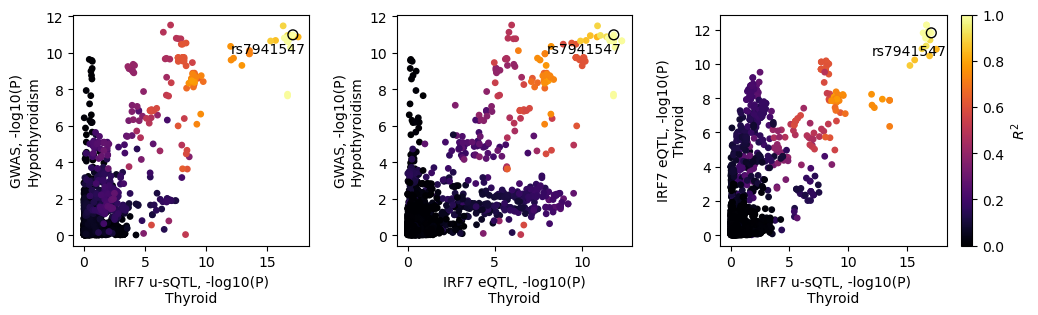

In [78]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(12, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nThyroid')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(8, 10, 'rs7941547')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nThyroid')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nThyroid')

x_r = -np.log10(np.array(nom.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(12, 10.5, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

plt.savefig('../code/plots/sup_hyperthyroid.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid.svg', dpi=300, bbox_inches='tight') 

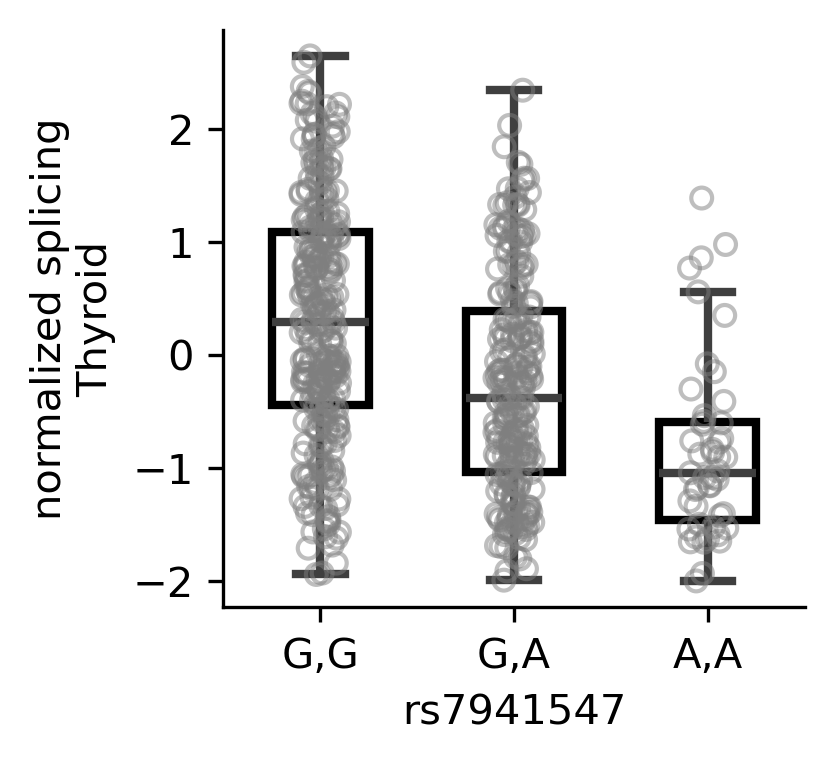

In [79]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

plt.savefig('../code/plots/sup_hyperthyroid_sp.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_sp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_sp.svg', dpi=300, bbox_inches='tight') 

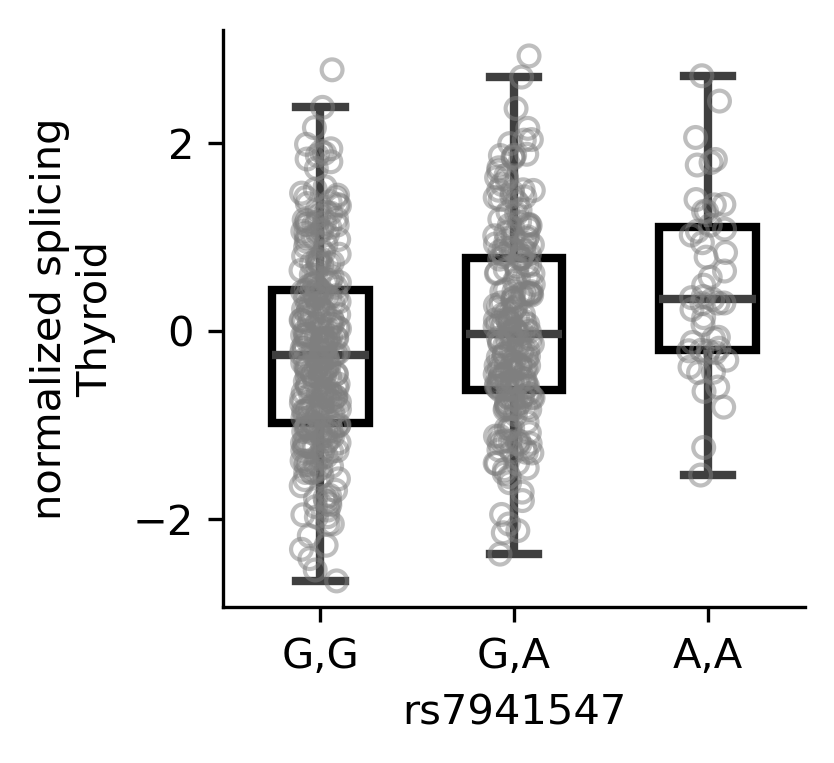

In [81]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

plt.savefig('../code/plots/sup_hyperthyroid_exp.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_exp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_exp.svg', dpi=300, bbox_inches='tight') 

In [107]:
      

  , 



plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000525445','ENST00000469048',])], 
                         'ENSG00000185507', 
                         colores=['tab:gray', 'tab:gray'],  figsize=(20, 1), lwidth=5, 
                         iso_order=['ENST00000525445','ENST00000469048'])

plt.savefig('../code/plots/sup_hyperthyroid_gene.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_gene.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_hyperthyroid_gene.svg', dpi=300, bbox_inches='tight') 

IndexError: list index out of range

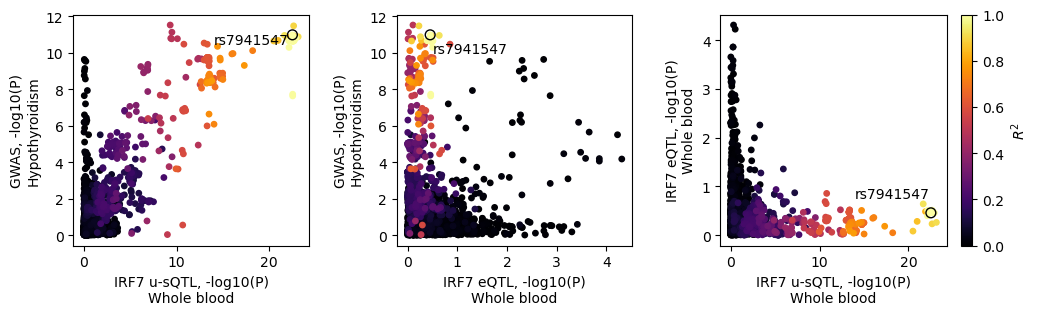

In [188]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_wb.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nWhole blood')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_wb.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(14, 10.5, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_wb_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[1].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nWhole blood')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_wb_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(0.5, 10, 'rs7941547')



x = -np.log10(np.array(nom_wb.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_wb_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[2].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nWhole blood')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nWhole blood')

x_r = -np.log10(np.array(nom_wb.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_wb_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(14, 0.75, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

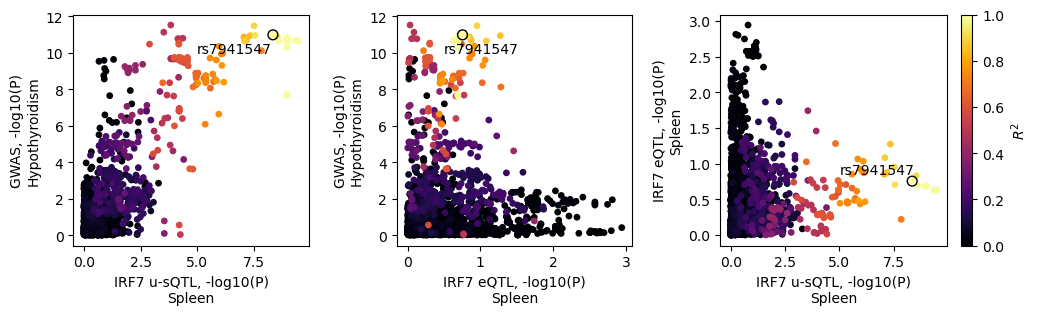

In [189]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_sp.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('IRF7 u-sQTL, -log10(P)\nSpleen')
ax[0].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_sp.loc[['chr11:611503']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(5, 10, 'rs7941547')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_sp_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[1].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('IRF7 eQTL, -log10(P)\nSpleen')
ax[1].set_ylabel('GWAS, -log10(P)\nHypothyroidism')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:611503']].P.astype(float)))
x_r = -np.log10(np.array(nom_sp_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(0.5, 10, 'rs7941547')



x = -np.log10(np.array(nom_sp.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_sp_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:611503', snps_shared]
scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[2].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('IRF7 u-sQTL, -log10(P)\nSpleen')
ax[2].set_ylabel('IRF7 eQTL, -log10(P)\nSpleen')

x_r = -np.log10(np.array(nom_sp.loc[['chr11:611503']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_sp_e.loc[['chr11:611503']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(5, 0.85, 'rs7941547')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [108]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_wb.index = qqnorm_wb.pid
qqnorm_lcl.index = qqnorm_lcl.pid

qqnorm_wb_e.index = qqnorm_wb_e.pid
qqnorm_lcl_e.index = qqnorm_lcl_e.pid

qqnorm_sp.index = qqnorm_sp.pid
qqnorm_sp_e.index = qqnorm_sp_e.pid

In [80]:
611503 - 614037

-2534

Text(0, 0.5, 'normalized splicing\nThyroid')

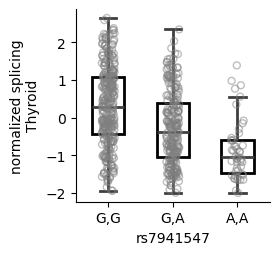

In [123]:
records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

Text(0, 0.5, 'normalized splicing\nWhole blood')

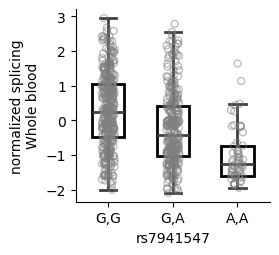

In [124]:
ax = make_boxplot_df(qqnorm_wb, 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nWhole blood')

Text(0, 0.5, 'normalized splicing\nLCLs')

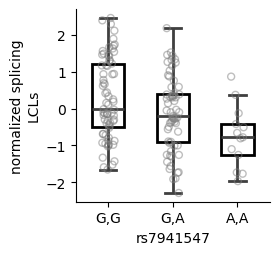

In [125]:
ax = make_boxplot_df(qqnorm_lcl, 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nLCLs')

In [132]:
qqnorm_lcl.loc['chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism']

#Chr                                                     chr11
start                                                    78759
end                                                    1078759
pid          chr11:614037:614475:clu_18165_-:UP:chr11_57875...
gid                                                clu_18165_-
                                   ...                        
GTEX-ZV6S                                 -0.40003245205282234
GTEX-ZV7C                                   0.3699174877733711
GTEX-ZVT2                                  -0.3901811393843457
GTEX-ZVZP                                  -0.6893761102072962
GTEX-ZXES                                 -0.15200848206785772
Name: chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism, Length: 153, dtype: object

Text(0, 0.5, 'normalized splicing\nSpleen')

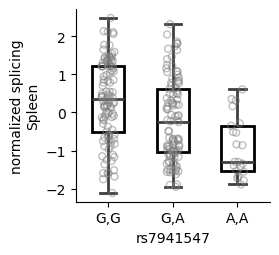

In [126]:
ax = make_boxplot_df(qqnorm_sp, 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nSpleen')

Text(0, 0.5, 'normalized expression\nSpleen')

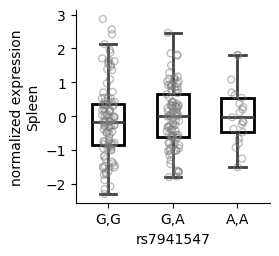

In [127]:
ax = make_boxplot_df(qqnorm_sp_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

Text(0, 0.5, 'normalized expression\nThyroid')

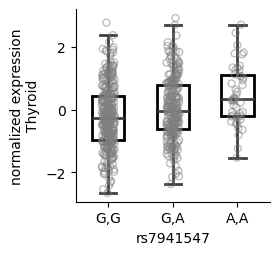

In [128]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nThyroid')

Text(0, 0.5, 'normalized expression\nWhole blood')

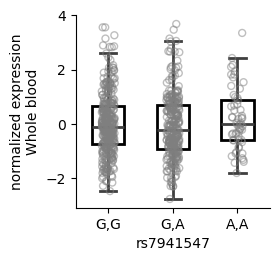

In [129]:
ax = make_boxplot_df(qqnorm_wb_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nWhole blood')

Text(0, 0.5, 'normalized expression\nLCLs')

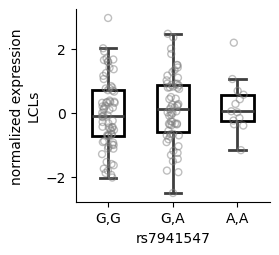

In [130]:
ax = make_boxplot_df(qqnorm_lcl_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nLCLs')

In [201]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-3000, 614475+3000)

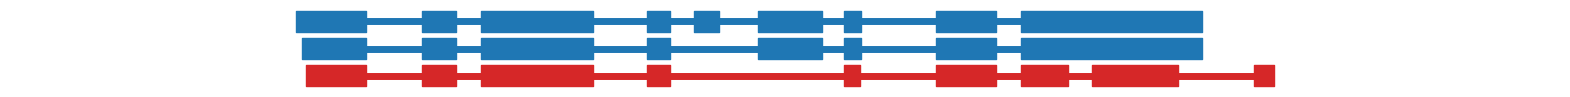

In [266]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000532326', 'ENST00000397570', 'ENST00000397566'])], 'ENSG00000185507', 
                         colores=['tab:blue', 'tab:blue', 'tab:red'], figsize=(20, 1), lwidth=5, iso_order=None)

In [138]:
hyprcoloc = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/annotated_results.tsv.gz', 
                 sep='\t')

In [260]:
hyprcoloc.loc[(hyprcoloc.tissue == 'Thyroid') & (hyprcoloc.gwas_trait == 'Hypothyroidism') & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs)]

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
8261,9,"chr11_578759_N_N_Hypothyroidism, Thyroid.leafc...",0.5976,0.7971,chr11_611503_G_A_b38,0.2252,NaN,Hypothyroidism,True,True,True,True,False,chr11_578759_N_N_Hypothyroidism,Thyroid
79828,2,"chr1_37942492_N_N_Hypothyroidism, Thyroid.leaf...",0.7005,0.9996,chr1_37997832_C_T_b38,0.8748,NaN,Hypothyroidism,True,True,True,True,False,chr1_37942492_N_N_Hypothyroidism,Thyroid
130500,2,"chr8_118965098_N_N_Hypothyroidism, Thyroid.lea...",0.8702,0.9936,chr8_118927620_A_G_b38,0.3648,NaN,Hypothyroidism,True,True,False,True,False,chr8_118965098_N_N_Hypothyroidism,Thyroid


In [207]:
annot.loc[(annot.gene_id == 'ENSG00000185507') & ((annot.start.astype(int)-614475).abs() <= 2)]

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
66,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000532096,retained_intron
67,chr11,614476,614531,ENSG00000185507,IRF7,-,protein_coding,ENST00000532326,nonsense_mediated_decay
68,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000397566,protein_coding
69,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000528413,nonsense_mediated_decay
70,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000532788,protein_coding_CDS_not_defined
71,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000330243,protein_coding
72,chr11,614476,614531,ENSG00000185507,IRF7,-,protein_coding,ENST00000649187,protein_coding
73,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000397570,protein_coding
74,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000348655,protein_coding
75,chr11,614476,614534,ENSG00000185507,IRF7,-,protein_coding,ENST00000469048,nonsense_mediated_decay


In [211]:
pheno = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Thyroid/separateNoise/leafcutter.qqnorm_chr11.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='pheno')
pheno['gid'] = pheno.pid.apply(lambda x: x.split(':')[3])

In [213]:
pheno.loc[pheno.gid == 'clu_22612_-']

,#Chr,start,end,pid,gid,strand,GTEX-111CU,GTEX-111FC,GTEX-111VG,GTEX-111YS,...,GTEX-ZY6K,GTEX-ZYFC,GTEX-ZYFD,GTEX-ZYFG,GTEX-ZYT6,GTEX-ZYVF,GTEX-ZYW4,GTEX-ZYY3,GTEX-ZZ64,GTEX-ZZPU
4,chr11,613865,613950,chr11:613865:613950:clu_22612_-:PR,clu_22612_-,-,1.073825372692674,-0.6105655447757671,-1.0107385485796814,-0.36917869033937395,...,-0.7617250252331236,0.3208906675016301,-1.145553772430914,1.3297378379117628,0.19122953882280677,-0.31385809251909463,0.5219703155068348,0.15882687731830894,0.6257997792579484,-2.0549869553886886
5,chr11,613865,614173,chr11:613865:614173:clu_22612_-:PR,clu_22612_-,-,-0.2920548038034449,-0.0005133836099403959,1.7426858217401433,-1.2417854752699178,...,-1.2247203586129212,0.6513348214159107,0.7198446860668718,-1.7224912347077201,0.12990826079513731,-0.2029871860277245,-1.3482565405951836,-1.580142868653783,-1.7566774870140085,1.0782877389269836
6,chr11,613865,614475,chr11:613865:614475:clu_22612_-:UP,clu_22612_-,-,-1.691196465817345,1.274847576951613,0.7851236879889409,2.1849293964296264,...,-0.07815328269278511,-1.55805306226051,-0.36655884048241894,-1.0217694483118878,0.26054441341172846,0.5886642183164695,-0.5911393500773129,-0.576186655169442,-0.5350181192777422,-0.9723446673289519
7,chr11,614037,614173,chr11:614037:614173:clu_22612_-:PR,clu_22612_-,-,-0.8191177211692825,-0.953675603338234,-0.8437427915944654,-0.6556372425401797,...,1.1511533516531722,0.8079382297552593,0.4329574412155046,-0.039171968694933244,0.18586962686844835,-0.4849121224759996,-1.2435518926524138,-0.2763200217898946,-1.57849357325616,-0.18541428265137652
8,chr11,614037,614475,chr11:614037:614475:clu_22612_-:UP,clu_22612_-,-,1.9292297841450936,1.3261137672959418,-0.535230780006395,-0.1310234609440502,...,-1.0401795606190882,-0.8776021776701655,-0.3981980641237222,-0.9016932684979128,-0.08692381949377082,-0.4539299942027146,1.4643266611198544,-0.06271337273853039,2.0767822911889424,-0.6113270449239859
9,chr11,614399,614475,chr11:614399:614475:clu_22612_-:PR,clu_22612_-,-,-2.256463922566849,-1.2123302499676893,0.660475649493975,0.30849721026682386,...,1.1519197309632117,0.3823447704137589,0.880701967970259,0.7494661309806993,0.6814801978837611,0.9958877357188476,-1.2622508864761741,0.826689662979682,-1.889634587531154,1.8731004801474411


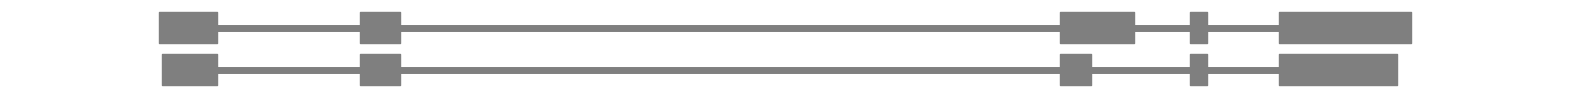

In [68]:
plot_isoform_annotations(aver.loc[aver.transcript_id.isin(['ENST00000589618', 'ENST00000293414'])], 'ENSG00000161664', 
                         colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [45]:
qqnorm.loc[qqnorm.gid == 'clu_29318_+']

,#Chr,start,end,pid,gid,strand,GTEX-111FC,GTEX-1128S,GTEX-117XS,GTEX-1192X,...,GTEX-ZAB4,GTEX-ZAJG,GTEX-ZAK1,GTEX-ZDXO,GTEX-ZF28,GTEX-ZUA1,GTEX-ZVT3,GTEX-ZYFD,GTEX-ZYY3,GTEX-ZZPT
8,chr17,44176940,44177608,chr17:44176940:44177608:clu_29318_+:UP,clu_29318_+,+,0.14919129561327452,0.33026203082050726,-0.13565181719026426,-0.4234379635271809,...,-0.9942050320948921,0.5698775026243534,1.789252543234058,0.7463727345999406,-1.3777680711298812,1.7535943175438458,1.2641072472757333,-0.1663348138304709,0.7221901966749597,-1.476438987046734
9,chr17,44177230,44177608,chr17:44177230:44177608:clu_29318_+:PR,clu_29318_+,+,-0.06339963362147508,-0.1912597006826638,0.23437139084289618,0.5608961811848097,...,1.030642165766667,-0.4418744555862646,-2.079078703705466,-0.7223010035852646,1.2063824566375816,-1.9570007524256448,-1.482730811515006,0.3559771362271294,-0.6298030509578074,1.292449494427552


In [69]:
best_df.loc[best_df.tissue.apply(lambda x: 'EBV' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
341,chr12:57694926:57695542:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.620360,2.068250e-12,0.156767,0.002946,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.017566,chr12,57694926,57695542,IMSGC2019,chr12_57713053_N_N_IMSGC2019
343,chr12:57695677:57695779:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,47,47,-0.623275,3.120300e-13,0.156767,0.002946,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.015642,chr12,57695677,57695779,IMSGC2019,chr12_57713053_N_N_IMSGC2019
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,5.346210e-06,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [77]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr22', 41515917-3000, 41517296+3000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Cells-EBV-transformedlymphocytes/separateNoise/leafcutter.qqnorm_chr22.gz', 
          'chr22', 41515917-3000, 41517296+3000, file_type='pheno')

In [78]:
qqnorm.loc[qqnorm.gid == 'clu_32769_+']

,#Chr,start,end,pid,gid,strand,GTEX-1122O,GTEX-11EM3,GTEX-11EMC,GTEX-11EQ9,...,GTEX-ZTPG,GTEX-ZTSS,GTEX-ZTTD,GTEX-ZTX8,GTEX-ZUA1,GTEX-ZV6S,GTEX-ZV7C,GTEX-ZVT2,GTEX-ZVZP,GTEX-ZXES
0,chr22,41515917,41517296,chr22:41515917:41517296:clu_32769_+:UP,clu_32769_+,+,-1.2039311403723763,-0.2397598681517509,-0.4366585592998314,-1.0862911231686434,...,-1.1562759242294973,-0.005734045712529302,1.4224748649302017,0.398433246762927,-1.1324495692010759,-0.19891542337821752,0.12403059550148271,1.1821033308401405,-0.735750291659711,0.510660406896069
1,chr22,41515917,41517526,chr22:41515917:41517526:clu_32769_+:PR,clu_32769_+,+,1.2758231288301685,0.43382621944553057,0.7031490005109816,1.0129312390784078,...,1.2194462737329776,-0.239889211855644,-1.3052286794536763,-0.021539565695331567,1.149558167419603,0.09671766093150728,0.13061900091008655,-1.1417455784486377,0.9942157867247303,-0.3115733989946682


In [85]:
annot.loc[(annot.gene_id == 'ENSG00000100412') & ((annot.end.astype(int) - 41515917).abs() <= 2)]

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
27,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000677554,protein_coding
28,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000677532,protein_coding
29,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000676664,nonsense_mediated_decay
30,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000677516,nonsense_mediated_decay
31,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000678788,protein_coding
32,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000678600,retained_intron
33,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000677007,nonsense_mediated_decay
34,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000677153,protein_coding
37,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000678454,retained_intron
38,chr22,41515767,41515917,ENSG00000100412,ACO2,+,protein_coding,ENST00000676822,protein_coding_CDS_not_defined


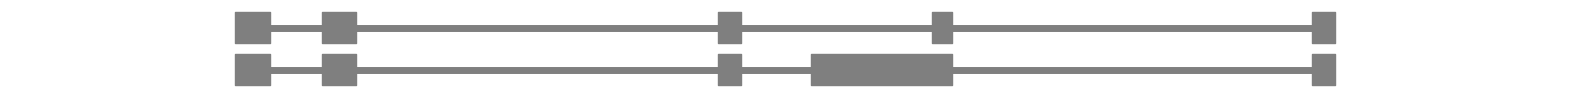

In [88]:


plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000678394', 'ENST00000677554'])], 'ENSG00000100412', 
                         colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [153]:
best_df.loc[best_df.tissue.apply(lambda x: 'EBV' in x)].intron.iloc[1]

'chr12:57695677:57695779:clu_19636_+:UP:chr12_57713053_N_N_IMSGC2019'

In [92]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr12', 57694926-3000, 57695779+3000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/Cells-EBV-transformedlymphocytes/separateNoise/leafcutter.qqnorm_chr12.gz', 
          'chr12', 57694926-3000, 57695779+3000, file_type='pheno')
# clu_19636_+	

In [94]:
qqnorm.loc[qqnorm.gid == 'clu_19636_+']

,#Chr,start,end,pid,gid,strand,GTEX-1122O,GTEX-11EM3,GTEX-11EMC,GTEX-11EQ9,...,GTEX-ZTPG,GTEX-ZTSS,GTEX-ZTTD,GTEX-ZTX8,GTEX-ZUA1,GTEX-ZV6S,GTEX-ZV7C,GTEX-ZVT2,GTEX-ZVZP,GTEX-ZXES
0,chr12,57694926,57695542,chr12:57694926:57695542:clu_19636_+:UP,clu_19636_+,+,-1.053217841573558,0.9012639771925137,-0.27310745114380025,0.3885881321449425,...,-1.0116725169009049,-0.8789915340484833,-1.0750799571164786,1.0131411821715173,-0.9956073490173298,-1.0054548824547662,1.1407212001998281,0.22400930525378968,-0.49390783497553736,0.06894129258375262
1,chr12,57694926,57695779,chr12:57694926:57695779:clu_19636_+:PR,clu_19636_+,+,0.9110220031806379,-0.931869714844941,0.4613674907319663,0.08387769659281326,...,1.0006226500462736,1.0310456171156404,1.1128604624178702,-0.5033360823642076,1.1761844342364252,0.9671791168779281,-0.2239126536774873,-0.6910506403563429,0.9027741450379143,0.6047619528216641
2,chr12,57695677,57695779,chr12:57695677:57695779:clu_19636_+:UP,clu_19636_+,+,-0.942006091541807,1.0611290975453607,-0.899284995508665,-0.1404806110111301,...,-0.9043809575761433,-0.7878710723611075,-0.9632743196110986,0.37419369352976195,-0.8897224410602523,-0.2225275437803364,-0.1966405967512211,0.9251007323608273,-0.9153125436954,-0.8244407914185671


In [107]:
annot.loc[annot.transcript_id.isin(['ENST00000552423', 'ENST00000700658'])]

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
15,chr12,57693841,57694323,ENSG00000135506,OS9,+,protein_coding,ENST00000700658,protein_coding
20,chr12,57694121,57694323,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
37,chr12,57694750,57694926,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
38,chr12,57694750,57694926,ENSG00000135506,OS9,+,protein_coding,ENST00000700658,protein_coding
69,chr12,57695543,57695677,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
71,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000700658,protein_coding
73,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
112,chr12,57695962,57696038,ENSG00000135506,OS9,+,protein_coding,ENST00000700658,protein_coding
125,chr12,57695962,57696038,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
137,chr12,57696275,57696373,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay


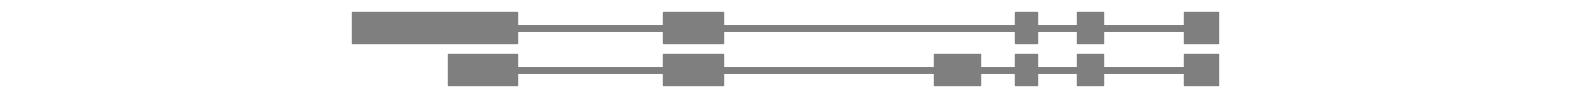

In [115]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000552423', 'ENST00000389142'])], 'ENSG00000135506', 
                         colores=['tab:gray']*3, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

In [106]:
annot.loc[(annot.start.astype(int)-57695779).abs() <= 2]

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
70,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000550848,nonsense_mediated_decay
71,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000700658,protein_coding
72,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000550699,retained_intron
73,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000552423,nonsense_mediated_decay
74,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000700660,nonsense_mediated_decay
75,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000553208,retained_intron
76,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000700666,protein_coding_CDS_not_defined
77,chr12,57695780,57695996,ENSG00000135506,OS9,+,protein_coding,ENST00000550793,retained_intron
78,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000700656,nonsense_mediated_decay
79,chr12,57695780,57695843,ENSG00000135506,OS9,+,protein_coding,ENST00000389142,protein_coding


In [97]:
qqnorm

,#Chr,start,end,pid,gid,strand,GTEX-1122O,GTEX-11EM3,GTEX-11EMC,GTEX-11EQ9,...,GTEX-ZTPG,GTEX-ZTSS,GTEX-ZTTD,GTEX-ZTX8,GTEX-ZUA1,GTEX-ZV6S,GTEX-ZV7C,GTEX-ZVT2,GTEX-ZVZP,GTEX-ZXES
0,chr12,57694926,57695542,chr12:57694926:57695542:clu_19636_+:UP,clu_19636_+,+,-1.053217841573558,0.9012639771925137,-0.27310745114380025,0.3885881321449425,...,-1.0116725169009049,-0.8789915340484833,-1.0750799571164786,1.0131411821715173,-0.9956073490173298,-1.0054548824547662,1.1407212001998281,0.22400930525378968,-0.49390783497553736,0.06894129258375262
1,chr12,57694926,57695779,chr12:57694926:57695779:clu_19636_+:PR,clu_19636_+,+,0.9110220031806379,-0.931869714844941,0.4613674907319663,0.08387769659281326,...,1.0006226500462736,1.0310456171156404,1.1128604624178702,-0.5033360823642076,1.1761844342364252,0.9671791168779281,-0.2239126536774873,-0.6910506403563429,0.9027741450379143,0.6047619528216641
2,chr12,57695677,57695779,chr12:57695677:57695779:clu_19636_+:UP,clu_19636_+,+,-0.942006091541807,1.0611290975453607,-0.899284995508665,-0.1404806110111301,...,-0.9043809575761433,-0.7878710723611075,-0.9632743196110986,0.37419369352976195,-0.8897224410602523,-0.2225275437803364,-0.1966405967512211,0.9251007323608273,-0.9153125436954,-0.8244407914185671
3,chr12,57695976,57696274,chr12:57695976:57696274:clu_19638_+:UP,clu_19638_+,+,-0.16584966923034497,-0.6825385571548991,1.4052317727126615,0.09918014779046443,...,-1.237554826424602,1.393770848835706,-1.0816549764917673,-0.5640612342799919,-1.8651638876035197,0.34983801763658856,-1.4001897468317686,-0.8743774014114327,-0.7603978698611332,-0.8021359796462537
4,chr12,57696038,57696274,chr12:57696038:57696274:clu_19638_+:PR,clu_19638_+,+,0.08037837575971359,0.7624131050888951,-1.6144484813986648,0.055215968121801344,...,1.2713690360937253,-1.962328581688126,0.47841976806506037,0.8868322619623354,1.67239108005923,-0.644052734661668,1.3116626225727064,0.9161726749436464,1.0014004607893832,0.8182335073266103


In [99]:
best_df.loc[best_df.intron.apply(lambda x: '_-:' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
165,chr11:614037:614475:clu_21453_-:UP:chr11_57875...,ENSG00000185507,chr11_614318_T_C_b38,0,157,-0.435814,1.138990e-14,0.155239,4.549520e-05,clu_21453_-,UP,Stomach,0.268905,chr11,614037,614475,Hypothyroidism,chr11_578759_N_N_Hypothyroidism
222,chr11:802376:802542:clu_21995_-:UP:chr11_80301...,ENSG00000177595,chr11_803017_A_G_b38,475,475,-0.302786,6.481420e-06,0.184477,9.285970e-06,clu_21995_-,UP,Pituitary,0.094601,chr11,802376,802542,GCST004988,chr11_803017_N_N_GCST004988
678,chr14:75135886:75139073:clu_30689_-:UP:chr14_7...,ENSG00000170348,chr14_75136131_A_T_b38,0,245,0.153227,4.203090e-05,-0.113077,8.210830e-07,clu_30689_-,UP,Testis,0.026357,chr14,75135886,75139073,coronary_artery_disease,chr14_74980176_N_N_coronary_artery_disease
799,chr15:68335814:68339499:clu_28898_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.339738,3.107650e-07,-0.073803,2.008080e-01,clu_28898_-,UP,Adipose-Visceral_Omentum,0.133663,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
801,chr15:68335814:68339499:clu_27730_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.900450,2.068970e-30,-0.143842,7.959240e-03,clu_27730_-,UP,Artery-Aorta,0.053730,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
805,chr15:68335814:68339499:clu_28397_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.716473,8.908570e-21,-0.048143,3.444100e-01,clu_28397_-,UP,Artery-Tibial,0.081830,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
807,chr15:68335814:68339499:clu_28369_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.329131,4.871640e-07,-0.044205,2.970690e-01,clu_28369_-,UP,Esophagus-Muscularis,0.147572,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
809,chr15:68335814:68339499:clu_27785_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.573819,1.945940e-12,-0.065886,3.893950e-01,clu_27785_-,UP,Heart-AtrialAppendage,0.129913,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
811,chr15:68335814:68339499:clu_26608_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.465196,1.491980e-08,-0.045575,5.623350e-01,clu_26608_-,UP,Heart-LeftVentricle,0.133663,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease
813,chr15:68335814:68339499:clu_29138_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.483679,1.136100e-12,-0.070191,2.706440e-01,clu_29138_-,UP,Nerve-Tibial,0.207921,chr15,68335814,68339499,Dupuytrens_disease,chr15_68333377_N_N_Dupuytrens_disease


In [293]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Multiple_sclerosis.standardized.txt.tabix.gz', 
          'chr12', 57694926-2000000, 57695779+2000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../code/resources/gwas/raw_summary_statistics_new/IMSGC2019.unstandardized.sorted.txt.gz', 
          'chr12', 57694926-2000000, 57695779+2000000)

gwas_pval['snp_pos'] = gwas_pval.chrom + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Cells-EBV-transformedlymphocytes/leafcutter.NominalPass/chr12.txt.tabix.gz',
               'chr12', 57694926-2000000, 57695779+2000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Cells-EBV-transformedlymphocytes/expression.NominalPass/chr12.txt.tabix.gz',
               'chr12', 57694926-2000000, 57695779+2000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


In [294]:
nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])

In [295]:
gwas.loc[gwas.loci == 'chr12_57713053_N_N_IMSGC2019']

,loci,chrom,start,beta,SE,A1,A2,snp_pos
0,chr12_57713053_N_N_IMSGC2019,chr12,57214555,-0.038013442198216174,0.0980697705194707,C,T,chr12:57214555
1,chr12_57713053_N_N_IMSGC2019,chr12,57214650,0.002796087302001188,0.017688685322643245,G,A,chr12:57214650
2,chr12_57713053_N_N_IMSGC2019,chr12,57216466,0.002596625847265914,0.01761371751820227,G,C,chr12:57216466
3,chr12_57713053_N_N_IMSGC2019,chr12,57217103,0.3295195511933606,0.20204096877361832,C,T,chr12:57217103
4,chr12_57713053_N_N_IMSGC2019,chr12,57217502,0.015971769509698665,0.042812286447162326,A,G,chr12:57217502
...,...,...,...,...,...,...,...,...
1887,chr12_57713053_N_N_IMSGC2019,chr12,58210603,0.08562708596743697,0.02653842349387243,C,T,chr12:58210603
1888,chr12_57713053_N_N_IMSGC2019,chr12,58210796,-0.030665414310885153,0.018318056355181127,G,A,chr12:58210796
1889,chr12_57713053_N_N_IMSGC2019,chr12,58210993,0.04707440738592885,0.018035591152875653,G,A,chr12:58210993
1890,chr12_57713053_N_N_IMSGC2019,chr12,58211033,0.030044121348376644,0.037554276869632405,C,T,chr12:58211033


In [296]:
gwas_pval.loc[gwas_pval.start.astype(int).isin(gwas.start.astype(int))]#.P.astype(float).mean(axis=1)

,#Chr,start,end,P,snpID,A1,A2,P,OR,chrom,windowStart,windowStop,loci,NOverlaps,snp_pos
0,chr12,57214555,57214556,0.6983,rs7956397,C,T,0.6983,0.9627,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:57214555
1,chr12,57214650,57214651,0.8744,rs7956686,G,A,0.8744,1.0028,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:57214650
2,chr12,57216466,57216467,0.8828,chr12:57610249,G,C,0.8828,1.0026,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:57216466
3,chr12,57217103,57217104,0.1029,chr12:57610886,C,T,0.1029,1.3903,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:57217103
4,chr12,57217502,57217503,0.7091,chr12:57611285,A,G,0.7091,1.0161,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:57217502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,chr12,58210603,58210604,0.001253,rs12816167,C,T,0.001253,1.0894,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:58210603
1888,chr12,58210796,58210797,0.09412,rs11172497,G,A,0.09412,0.9698,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:58210796
1889,chr12,58210993,58210994,0.009052,rs7310107,G,A,0.009052,1.0482,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:58210993
1890,chr12,58211033,58211034,0.4237,rs7974614,C,T,0.4237,1.0305,chr12,57213053,58213053,chr12_57713053_N_N_IMSGC2019,1,chr12:58211033


In [299]:
nom.index = nom.snp_pos
nom_e.index = nom_e.snp_pos

In [300]:
gwas_pval.index = gwas_pval.snp_pos
gwas.index = gwas.snp_pos

In [301]:
snps

Index(['chr12:57214650', 'chr12:57216466', 'chr12:57217502', 'chr12:57219642',
       'chr12:57219997', 'chr12:57220701', 'chr12:57222230', 'chr12:57222278',
       'chr12:57224636', 'chr12:57224836',
       ...
       'chr12:58202832', 'chr12:58203787', 'chr12:58205634', 'chr12:58205746',
       'chr12:58208910', 'chr12:58210603', 'chr12:58210796', 'chr12:58210993',
       'chr12:58211033', 'chr12:58212393'],
      dtype='object', name='snp_pos', length=1344)

In [291]:
nom_e

,#phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit,snp_pos,gwas_trait
snp_pos,,,,,,,,,,,,,,,,,,
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_57214650_G_A_b38,chr12,57214650,57214650,0.615526,0.00174384,0.0250384,0.0497496,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_57216251_A_C_b38,chr12,57216251,57216251,0.900833,0.000107451,0.0216686,0.173587,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_57216466_G_C_b38,chr12,57216466,57216466,0.615774,0.00174139,0.0247289,0.0491692,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_57217502_A_G_b38,chr12,57217502,57217502,0.964837,1.34491e-05,-0.00408893,0.0925924,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_57218983_TTG_T_b38,chr12,57218983,57218985,0.863076,0.000205807,0.00789332,0.0456879,0,NaN,chr12_57713053_N_N_IMSGC2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_58210796_G_A_b38,chr12,58210796,58210796,0.682987,0.00115353,0.0242581,0.0592798,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_58210993_G_A_b38,chr12,58210993,58210993,0.0262771,0.0335931,-0.117433,0.0523073,0,NaN,chr12_57713053_N_N_IMSGC2019
NaN,ENSG00000135506.16:chr12_57713053_N_N_IMSGC2019,chr12,57213054,58213053,+,1622,0,chr12_58211033_C_T_b38,chr12,58211033,58211033,0.0741188,0.0218297,0.15341,0.0852814,0,NaN,chr12_57713053_N_N_IMSGC2019


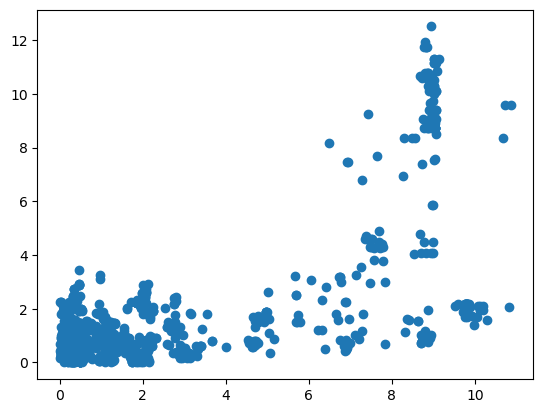

In [210]:
plt.scatter(x, y)

In [215]:
gwas.loc[gwas.snp_pos== 'chr12:57713053']

,loci,chrom,start,beta,SE,A1,A2,snp_pos
snp_pos,,,,,,,,
chr12:57713053,chr12_57713053_N_N_IMSGC2019,chr12,57713053,0.11386425614904713,0.016835650322539496,G,A,chr12:57713053


In [302]:
LD = pd.read_csv('../code/results/coloc/LD/chr12_57713053_N_N_IMSGC2019.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)

In [303]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float).mean(axis=1)))
y = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr12:57713053', snps_shared]
plt.scatter(x, y, c=r2)

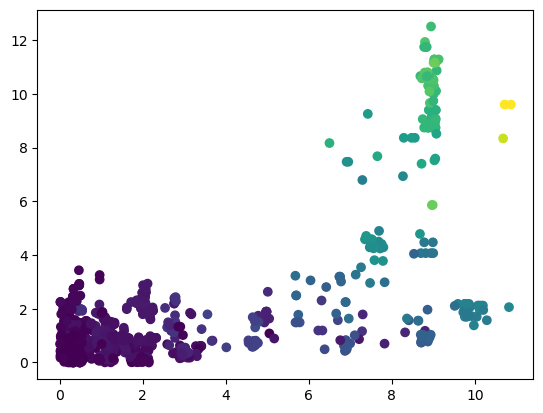

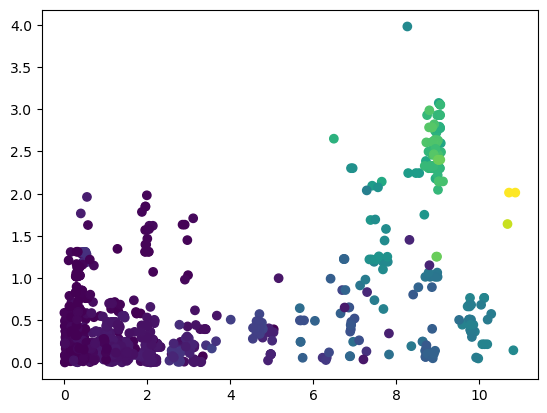

In [308]:
x = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float).mean(axis=1)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
plt.scatter(x, y, c=r2)

In [216]:
nom.loc[nom.snp_pos == 'chr12:57713053']

,#phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit,snp_pos,gwas_trait
snp_pos,,,,,,,,,,,,,,,,,,
chr12:57713053,chr12:57695677:57695779:clu_19636_+:UP:chr12_5...,chr12,57213054,58213053,+,1622,0,chr12_57713053_A_G_b38,chr12,57713053,57713053,2.51041e-10,0.241907,-0.534681,0.0786046,0,chr12:57713053,chr12_57713053_N_N_IMSGC2019


In [225]:
import pysam
import pysam

def extract_genotypes(vcf_file, region):
    """
    Extract genotypes from a VCF file in a given region without using pyvcf.
    
    Parameters:
    - vcf_file (str): Path to the VCF file (must be bgzipped and indexed).
    - region (str): Region to query, formatted as 'chrom:start-end' (1-based).
    
    Returns:
    - genotypes (dict): Dictionary of variant positions and sample genotypes.
    """
    genotypes = {}
    
    # Open the VCF file using pysam
    with pysam.TabixFile(vcf_file) as tabix_file:
        try:
            # Fetch lines from the specified region
            region_lines = tabix_file.fetch(region=region)
            
            for line in region_lines:
                # Skip header lines
                if line.startswith("#"):
                    continue
                
                # Parse the VCF line
                fields = line.strip().split('\t')
                chrom, pos, _, _, _, _, _, info, format_field, *samples = fields
                
                # Extract genotype field index
                format_keys = format_field.split(':')
                try:
                    gt_index = format_keys.index('GT')
                except ValueError:
                    print(f"Genotype field 'GT' not found in format for variant at {pos}.")
                    continue
                
                # Extract genotypes for all samples
                sample_genotypes = [sample.split(':')[gt_index] for sample in samples]
                
                # Store genotypes with the position as the key
                genotypes[int(pos)] = sample_genotypes
        except ValueError:
            print(f"Region {region} not found in the VCF file.")
    
    return genotypes


# Example usage
vcf_file = "/project/yangili1/cfbuenabadn/SpliFi/code/results/geno/GTEx/Cells-EBV-transformedlymphocytes/chr12.vcf.gz"  # VCF file (bgzipped and indexed with tabix)
region = "chr12:56694926-58695779"  # Region to query

genotypes = extract_genotypes(vcf_file, region)

In [235]:
genotypes.

In [229]:
for pos, sample_genotypes in genotypes.items():
    break

In [230]:
pos

56699312

In [254]:
import pysam
import numpy as np

def extract_genotypes_and_positions(vcf_file, region):
    """
    Extract genotypes and variant positions from a VCF file in a given region.

    Parameters:
    - vcf_file (str): Path to the VCF file (must be bgzipped and indexed).
    - region (str): Region to query, formatted as 'chrom:start-end' (1-based).

    Returns:
    - positions (list): List of variant positions.
    - genotype_matrix (numpy.ndarray): A matrix of genotypes (samples x variants).
    """
    positions = []
    genotypes = []

    with pysam.TabixFile(vcf_file) as tabix_file:
        try:
            region_lines = tabix_file.fetch(region=region)
            for line in region_lines:
                if line.startswith("#"):
                    continue

                # Parse the VCF line
                fields = line.strip().split('\t')
                pos = int(fields[1])
                format_field = fields[8]
                samples = fields[9:]

                # Extract genotype field
                format_keys = format_field.split(':')
                try:
                    gt_index = format_keys.index('GT')
                except ValueError:
                    print(f"Genotype field 'GT' not found in format for variant at {pos}.")
                    continue

                # Convert genotypes to numeric values (0, 1, 2, or NaN for missing)
                genotype_values = []
                for sample in samples:
                    gt = sample.split(':')[gt_index]
                    if gt == './.':
                        genotype_values.append(np.nan)
                    else:
                        alleles = gt.replace('|', '/').split('/')
                        genotype_values.append(sum(map(int, alleles)))

                positions.append(pos)
                genotypes.append(genotype_values)

        except ValueError:
            print(f"Region {region} not found in the VCF file.")

    genotype_matrix = np.array(genotypes).T  # Transpose to samples x variants
    return positions, genotype_matrix


def compute_ld_r2(genotype_matrix):
    """
    Compute the linkage disequilibrium (r2) between all pairs of variants.

    Parameters:
    - genotype_matrix (numpy.ndarray): A matrix of genotypes (samples x variants).

    Returns:
    - r2_matrix (numpy.ndarray): A symmetric matrix of r2 values (variants x variants).
    """
    # Standardize the genotype matrix (center and scale each column)
    standardized_matrix = (genotype_matrix - np.nanmean(genotype_matrix, axis=0)) / np.nanstd(genotype_matrix, axis=0)
    standardized_matrix = np.nan_to_num(standardized_matrix)  # Replace NaN with 0

    # Compute the correlation matrix
    correlation_matrix = np.corrcoef(standardized_matrix.T)

    # Square the correlation matrix to get r2 values
    r2_matrix = np.square(correlation_matrix)
    return r2_matrix


# Example usage
vcf_file = "/project/yangili1/cdai/genome_index/hs38/GTEx_v7/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz"  # VCF file (bgzipped and indexed with tabix)
region = "chr12:57214648-58212395"  # Region to query

positions, genotype_matrix = extract_genotypes_and_positions(vcf_file, region)
r2_matrix = compute_ld_r2(genotype_matrix)


Region chr12:57214648-58212395 not found in the VCF file.


In [260]:
hyprcoloc.gwas_trait.unique()

array(['Visceral_adipose_tissue_measurement', 'atrial_fibrillation',
       'age_when_finished_full-time_education', 'GCST007800',
       'schizophrenia', 'myocardial_infarction',
       'coronary_artery_disease', 'Chronic_obstructive_pulmonary_disease',
       'basal_cell_carcinoma', 'bipolar_disorder', 'GCST004132',
       'GCST004131', 'GCST004988', 'heart_failure', 'Dupuytrens_disease',
       'Hypothyroidism', 'Atopic_eczema', 'GCST004133',
       'Rheumatoid_arthritis', 'IMSGC2019'], dtype=object)

In [271]:
hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs) & (hyprcoloc.gwas_trait == 'schizophrenia')
].sort_values('posterior_explained_by_snp').tail(50)

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
16371,2,"chr12_124002131_N_N_schizophrenia, Testis.leaf...",0.5577,0.9959,chr12_123943615_T_A_b38,0.1270,NaN,schizophrenia,True,True,True,True,True,chr12_124002131_N_N_schizophrenia,Testis
27596,2,"chr15_43536810_N_N_schizophrenia, Ovary.leafcu...",0.2999,0.5852,chr15_43788539_T_C_b38,0.1834,NaN,schizophrenia,True,True,True,True,False,chr15_43536810_N_N_schizophrenia,Ovary
27497,2,"chr15_43536810_N_N_schizophrenia, Artery-Coron...",0.5287,0.9905,chr15_43636872_C_G_b38,0.2071,NaN,schizophrenia,True,True,True,True,False,chr15_43536810_N_N_schizophrenia,Artery-Coronary
39975,5,"chr16_90042964_N_N_schizophrenia, Testis.leafc...",0.5786,0.9541,chr16_89770464_T_C_b38,0.2201,NaN,schizophrenia,True,True,True,True,False,chr16_90042964_N_N_schizophrenia,Testis
38773,6,"chr16_89492889_N_N_schizophrenia, Testis.leafc...",0.5459,0.9541,chr16_89770464_T_C_b38,0.2201,NaN,schizophrenia,True,True,True,True,False,chr16_89492889_N_N_schizophrenia,Testis
109339,2,"chr3_52781889_N_N_schizophrenia, Artery-Tibial...",0.4197,0.6227,chr3_52686064_A_C_b38,0.2473,NaN,schizophrenia,True,True,True,True,False,chr3_52781889_N_N_schizophrenia,Artery-Tibial
108782,1,"chr3_52274829_N_N_schizophrenia, Artery-Tibial...",0.3958,0.6227,chr3_52686064_A_C_b38,0.2473,NaN,schizophrenia,True,True,True,True,False,chr3_52274829_N_N_schizophrenia,Artery-Tibial
27617,2,"chr15_43536810_N_N_schizophrenia, Stomach.leaf...",0.4653,0.8535,chr15_43782086_A_G_b38,0.2537,NaN,schizophrenia,True,True,True,True,False,chr15_43536810_N_N_schizophrenia,Stomach
27538,2,"chr15_43536810_N_N_schizophrenia, Breast-Mamma...",0.4630,0.9242,chr15_43738381_G_A_b38,0.2802,NaN,schizophrenia,True,True,True,True,False,chr15_43536810_N_N_schizophrenia,Breast-MammaryTissue
34014,3,"chr16_29983601_N_N_schizophrenia, Esophagus-Mu...",0.7172,0.9771,chr16_29946895_G_A_b38,0.3594,NaN,schizophrenia,True,True,True,True,False,chr16_29983601_N_N_schizophrenia,Esophagus-Muscularis


In [272]:
hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs)].loc[27514].traits

'chr15_43536810_N_N_schizophrenia, Brain-CerebellarHemisphere.leafcutter_N_N_chr15:43632363:43632716:clu_25812_-:PR:ENSG00000166762.16, Brain-CerebellarHemisphere.leafcutter_N_N_chr15:43632363:43635359:clu_25812_-:UP:ENSG00000166762.16, Brain-CerebellarHemisphere.leafcutter_N_N_chr15:43632928:43635359:clu_25812_-:PR:ENSG00000166762.16, Brain-CerebellarHemisphere.leafcutter_N_N_chr15:43632934:43635359:clu_25812_-:PR:ENSG00000166762.16, Brain-CerebellarHemisphere.expression_N_N_ENSG00000242866'

In [ ]:
nom_df.loc[nom_df.intron.apply(lambda x: 'chr22:41515917:41517296:clu_32769_+:UP' in x )]

In [275]:
nom_df.loc[nom_df.var_id.apply(lambda x: 'chr17_44176913' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1083,chr17:44176940:44177608:clu_28859_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.622274,2.053880e-11,0.246418,6.448610e-08,clu_28859_+,UP,Brain-CerebellarHemisphere,0.504950,chr17,44176940,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1084,chr17:44177230:44177608:clu_28859_+:PR:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,317,317,0.597825,3.256080e-10,0.246418,6.448610e-08,clu_28859_+,PR,Brain-CerebellarHemisphere,0.958982,chr17,44177230,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1085,chr17:44176940:44177608:clu_29318_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.594865,3.708880e-13,0.209502,2.003820e-05,clu_29318_+,UP,Brain-Cerebellum,0.538969,chr17,44176940,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1086,chr17:44177230:44177608:clu_29318_+:PR:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,317,317,0.588879,1.421030e-12,0.209502,2.003820e-05,clu_29318_+,PR,Brain-Cerebellum,0.971711,chr17,44177230,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1093,chr17:44176940:44177608:clu_30688_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.274685,2.305000e-06,0.106021,2.040830e-04,clu_30688_+,UP,Heart-AtrialAppendage,0.339934,chr17,44176940,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1094,chr17:44177230:44177608:clu_30688_+:PR:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,317,317,0.302822,9.644110e-07,0.106021,2.040830e-04,clu_30688_+,PR,Heart-AtrialAppendage,1.000000,chr17,44177230,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1101,chr17:44176940:44177608:clu_30688_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.274685,2.305000e-06,0.106021,2.040830e-04,clu_30688_+,UP,Heart-AtrialAppendage,0.339934,chr17,44176940,44177608,Visceral_adipose_tissue_measurement,chr17_44201548_N_N_Visceral_adipose_tissue_mea...
1102,chr17:44177230:44177608:clu_30688_+:PR:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,317,317,0.302822,9.644110e-07,0.106021,2.040830e-04,clu_30688_+,PR,Heart-AtrialAppendage,1.000000,chr17,44177230,44177608,Visceral_adipose_tissue_measurement,chr17_44201548_N_N_Visceral_adipose_tissue_mea...


In [269]:
nom_df.loc[nom_df.intron.apply(lambda x: 'chr22:41515917:41517296:clu_32769_+:UP' in x )]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,0.000005,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [83]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')


qqnorm_bm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_bm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

In [98]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['#Chr'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_bm = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['#phe_id'].apply(lambda x: x.split(':')[-1])








In [99]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['#phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb['#phe_id'] == 'chr11:802376:802542:clu_19976_-:UP:chr11_803017_N_N_GCST004988')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_wb_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl['#phe_id'] == 'chr11:802376:802542:clu_18186_-:UP:chr11_803017_N_N_GCST004988')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]

nom_bm = nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm['#phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')]
nom_bm_e = nom_bm_e.loc[(nom_bm_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm_e['#phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))#.intersection(pd.Index(nom_bm_e.snp_pos)).intersection(pd.Index(nom_bm.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

# nom_wb = nom_wb.groupby('snp_pos').first()
# nom_wb_e = nom_wb_e.groupby('snp_pos').first()

# nom_sp = nom_sp.groupby('snp_pos').first()
# nom_sp_e = nom_sp_e.groupby('snp_pos').first()

In [100]:
LD = pd.read_csv('../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



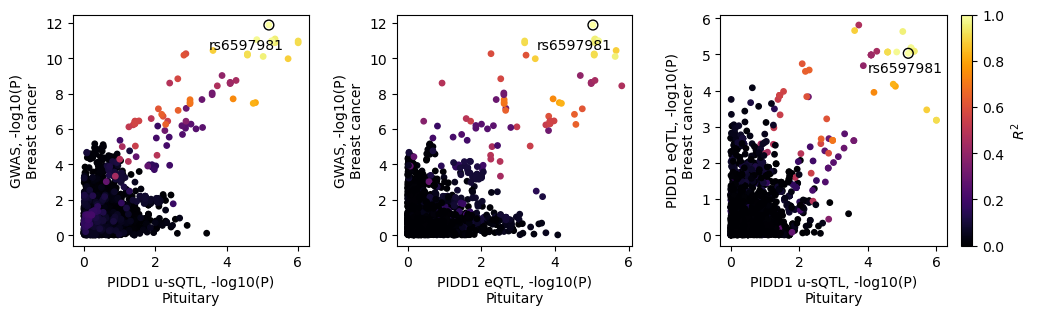

In [101]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [102]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_wb.index = qqnorm_wb.pid
qqnorm_lcl.index = qqnorm_lcl.pid

qqnorm_wb_e.index = qqnorm_wb_e.pid
qqnorm_lcl_e.index = qqnorm_lcl_e.pid

qqnorm_bm.index = qqnorm_bm.pid
qqnorm_bm_e.index = qqnorm_bm_e.pid

Text(0, 0.5, 'normalized splicing\nPituitary')

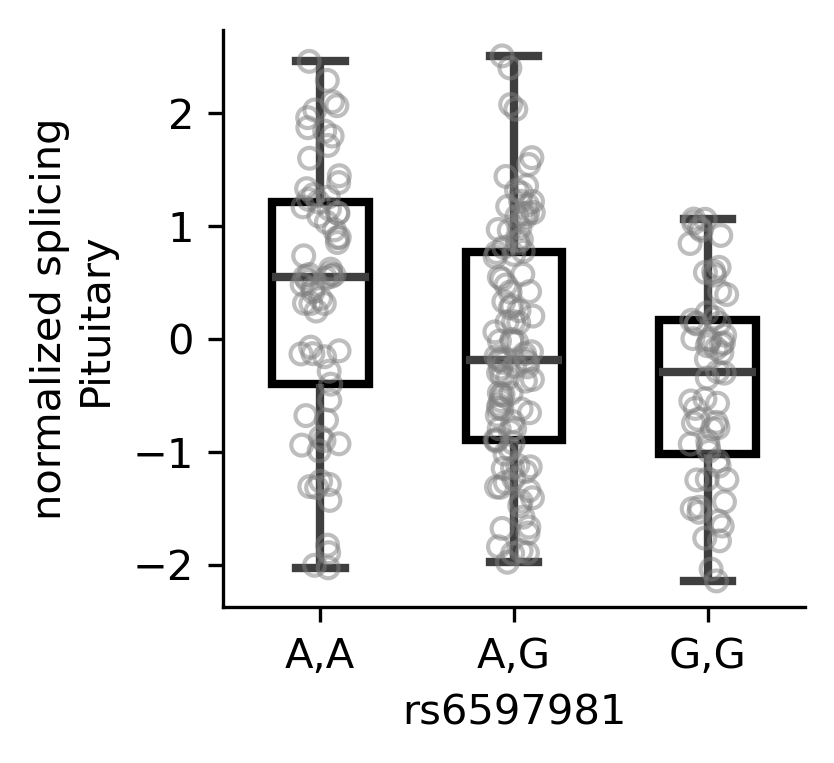

In [103]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nPituitary')

Text(0, 0.5, 'normalized splicing\nBreast mammary tissue')

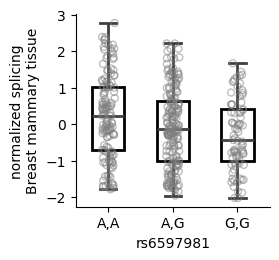

In [246]:
records = get_best_snp_record(vcf_gtex, 'chr11:803017')

ax = make_boxplot_df(qqnorm_bm, 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBreast mammary tissue')

Text(0, 0.5, 'normalized expression\nSpleen')

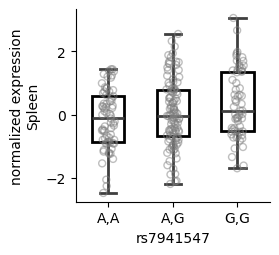

In [236]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

Text(0, 0.5, 'normalized expression\nBreast mammary tissue')

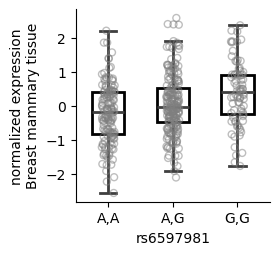

In [247]:
ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nBreast mammary tissue')

In [171]:
hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs)].loc[80030].traits

'chr1_37995647_N_N_coronary_artery_disease, Artery-Tibial.leafcutter_N_N_chr1:37997870:37998973:clu_2530_-:UP:ENSG00000183386.9, Artery-Tibial.leafcutter_N_N_chr1:37998132:37998973:clu_2530_-:PR:ENSG00000183386.9, Artery-Tibial.expression_N_N_ENSG00000183386, Artery-Tibial.expression_N_N_ENSG00000183520'

In [172]:
nom_df.loc[nom_df.intron.apply(lambda x: 'chr1:37997870:37998973:clu_2530_-:UP' in x )]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1601,chr1:37997870:37998973:clu_2530_-:UP:chr1_3794...,ENSG00000183386,chr1_37979982_T_A_b38,17888,17888,-0.300973,1.628450e-13,0.364808,6.986200e-39,clu_2530_-,UP,Artery-Tibial,0.103151,chr1,37997870,37998973,Hypothyroidism,chr1_37942492_N_N_Hypothyroidism
1699,chr1:37997870:37998973:clu_2530_-:UP:chr1_3799...,ENSG00000183386,chr1_37979077_T_C_b38,18793,18793,-0.295655,1.346830e-12,0.362074,1.384960e-36,clu_2530_-,UP,Artery-Tibial,0.103151,chr1,37997870,37998973,coronary_artery_disease,chr1_37995647_N_N_coronary_artery_disease


In [12]:
nom_df.loc[nom_df.var_id.apply(lambda x: 'chr17_44176913' in x)].loc[1085]#.intron


intron          chr17:44176940:44177608:clu_29318_+:UP:chr17_4...
gene                                              ENSG00000161664
var_id                                     chr17_44176913_A_G_b38
distance                                                       27
distance_abs                                                   27
sQTL_beta                                               -0.594865
sQTL_pval                                                     0.0
eQTL_beta                                                0.209502
eQTL_pval                                                 0.00002
cluster                                               clu_29318_+
itype                                                          UP
tissue                                           Brain-Cerebellum
PSI                                                      0.538969
chrom                                                       chr17
start                                                    44176940
end       

In [13]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-Cerebellum/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-Cerebellum/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')

qqnorm_bch = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_bch_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')


qqnorm_ms = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Muscle-Skeletal/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_ms_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Muscle-Skeletal/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')


In [15]:
qqnorm_ms.loc[qqnorm_ms.pid.apply(lambda x: '44176940:44177608' in x) & (qqnorm_ms.pid.apply(lambda x: 'chr17_44114525_N_N_bipolar_disorder' in x))].pid.iloc[0]

'chr17:44176940:44177608:clu_30815_+:UP:chr17_44114525_N_N_bipolar_disorder'

In [16]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Bipolar_disorder.standardized.txt.tabix.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/gwas/hg38_summary_stats/bipolar_disorder.bed.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Brain-Cerebellum/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Brain-Cerebellum/expression.NominalPass/chr17.txt.tabix.gz',
              'chr17', 44176940-1000000, 44177608+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['#phe_id'].apply(lambda x: x.split(':')[-1])





nom_bch = run_tabix('../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch['snp_pos'] = nom_bch.var_chr + ':' + nom_bch.var_from


nom_bch_e = run_tabix('../code/results/coloc/qtls/Brain-CerebellarHemisphere/expression.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch_e['snp_pos'] = nom_bch_e.var_chr + ':' + nom_bch_e.var_from

nom_bch['gwas_trait'] = nom_bch['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_bch_e['gwas_trait'] = nom_bch_e['#phe_id'].apply(lambda x: x.split(':')[-1])



nom_ms = run_tabix('../code/results/coloc/qtls/Muscle-Skeletal/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_ms['snp_pos'] = nom_ms.var_chr + ':' + nom_ms.var_from


nom_ms_e = run_tabix('../code/results/coloc/qtls/Muscle-Skeletal/expression.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_ms_e['snp_pos'] = nom_ms_e.var_chr + ':' + nom_ms_e.var_from

nom_ms['gwas_trait'] = nom_ms['#phe_id'].apply(lambda x: x.split(':')[-1])
nom_ms_e['gwas_trait'] = nom_ms_e['#phe_id'].apply(lambda x: x.split(':')[-1])






In [17]:
nom = nom.loc[(nom.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom['#phe_id'] == 'chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]

nom_bch = nom_bch.loc[(nom_bch.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch['#phe_id'] == 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_bch_e = nom_bch_e.loc[(nom_bch_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]


nom_ms = nom_ms.loc[(nom_ms.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_ms['#phe_id'] == 'chr17:44176940:44177608:clu_30815_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_ms_e = nom_ms_e.loc[(nom_ms_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_ms_e['#phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]




snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos)).intersection(pd.Index(nom_bch_e.snp_pos)).intersection(pd.Index(nom_bch.snp_pos)).intersection(pd.Index(nom_ms_e.snp_pos)).intersection(pd.Index(nom_ms.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()

nom_bch = nom_bch.groupby('snp_pos').first()
nom_bch_e = nom_bch_e.groupby('snp_pos').first()

nom_ms = nom_ms.groupby('snp_pos').first()
nom_ms_e = nom_ms_e.groupby('snp_pos').first()

In [18]:
nom_bch.loc['chr17:44176913'].slope

'-0.622274'

In [19]:
LD = pd.read_csv('../code/results/coloc/LD/chr17_44114525_N_N_bipolar_disorder.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



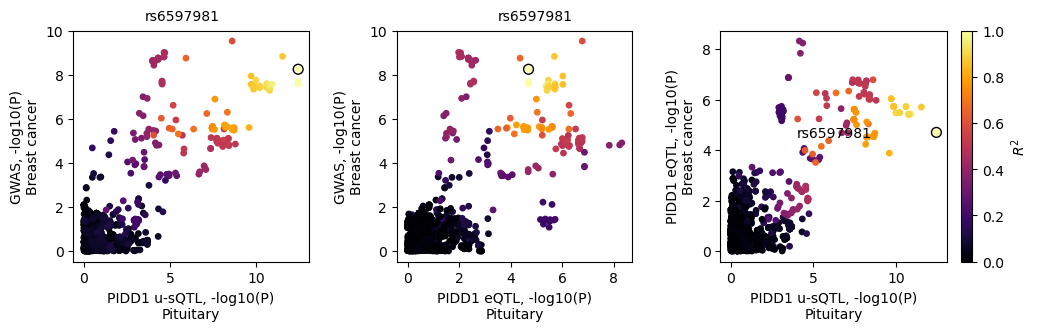

In [20]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

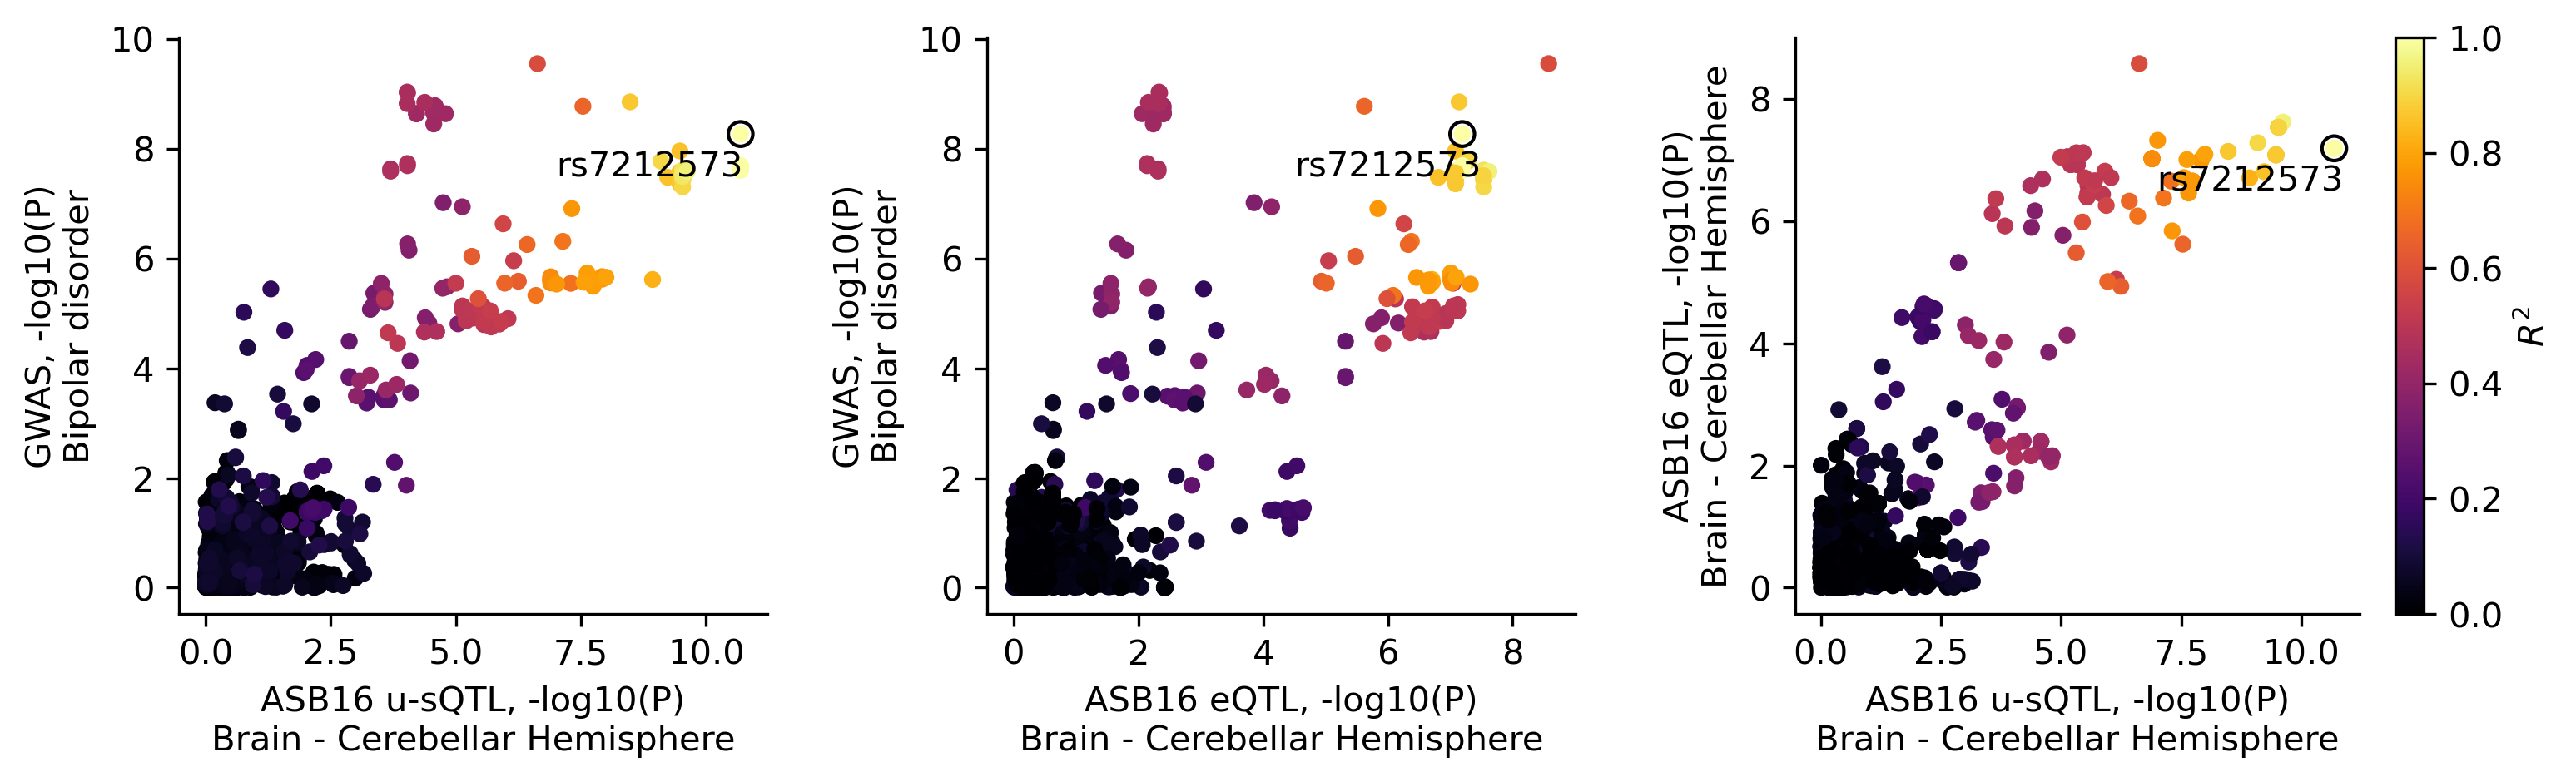

In [21]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2], dpi=300)
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[0].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(7, 7.5, 'rs7212573')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[1].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(4.5, 7.5, 'rs7212573')



x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[2].set_ylabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')

x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(7, 6.5, 'rs7212573')

ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[2].spines[['top', 'right']].set_visible(False)

fig.subplots_adjust(wspace=0.35, hspace=5)

# plt.savefig('../code/plots/fig4_coloc_example.png', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4_coloc_example.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4_coloc_example.svg', dpi=300, bbox_inches='tight')

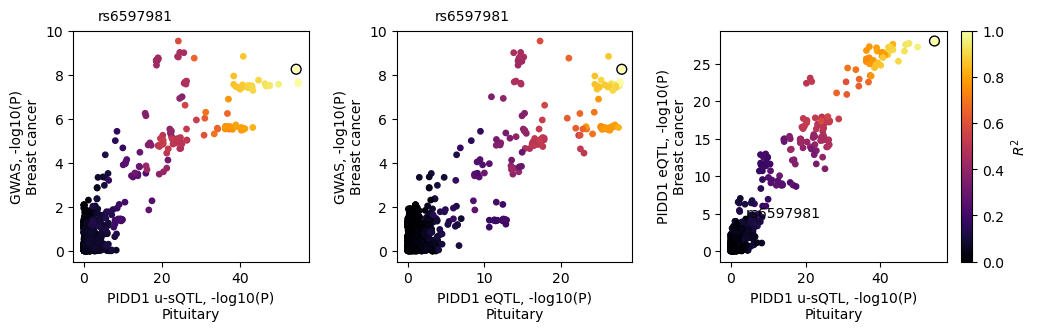

In [22]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_ms.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_ms.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_ms_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_ms_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom_ms.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_ms_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom_ms.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_ms_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [23]:
qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_bch.index = qqnorm_bch.pid
qqnorm_bch_e.index = qqnorm_bch_e.pid

qqnorm_ms.index = qqnorm_ms.pid
qqnorm_ms_e.index = qqnorm_ms_e.pid

Text(0, 0.5, 'normalized splicing\nBrain Cerebellum')

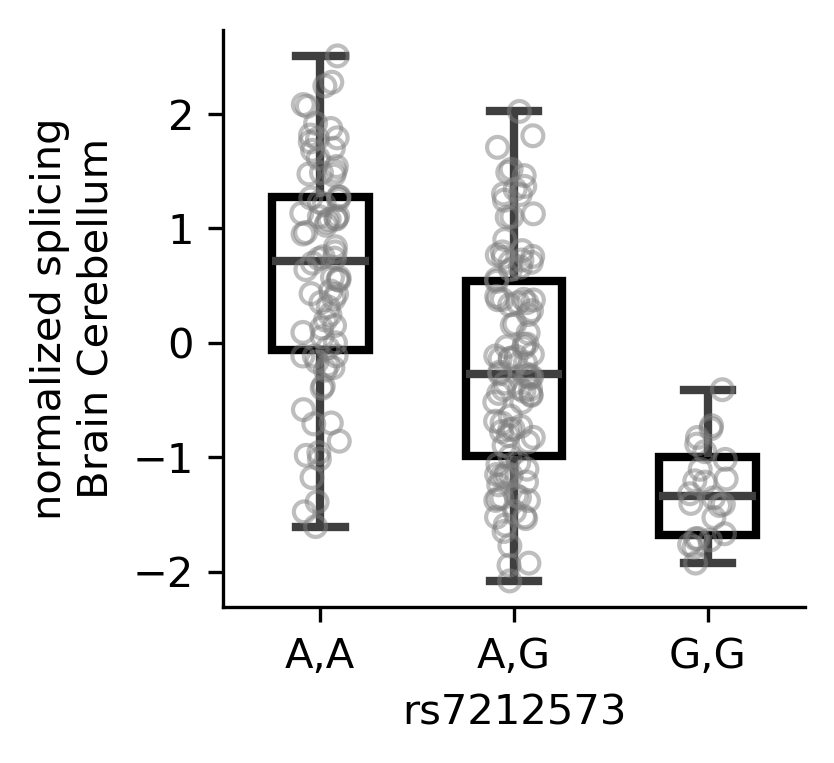

In [28]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm, 'chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('normalized splicing\nBrain Cerebellum')


In [29]:
from scipy.stats import t

# Given values
slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)
n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error


In [30]:
nom_bch.loc['chr17:44176913'].nom_pval

'2.05388e-11'

In [31]:
nom_bch.loc['chr17:44176913'].slope

'-0.622274'

In [41]:
   
def make_boxplot_df_colored(qqnorm_data, phenotype, record, phenotype_class='', color='black'):
    qq_samples = qqnorm_data.columns[6:]
    hom_refs = [str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = [str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = [str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.REF
    alt = record.ALT[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    # if color_by_phenotype:
    #     colores = [color_by_phenotype]*3

    # else:
    #     colores = ['red', 'purple', 'blue']#ColorPallette#list(plt.get_cmap('tab10').colors)
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.8, showfliers=False,
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor=color),
           whiskerprops = dict(color=color),
           capprops = dict(color=color),
           medianprops = dict(linewidth=2, color='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.9, edgecolor=color, facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    return ax

Text(1.5, 1, '$\\beta = -0.62$\np-val $< 1e-10$')

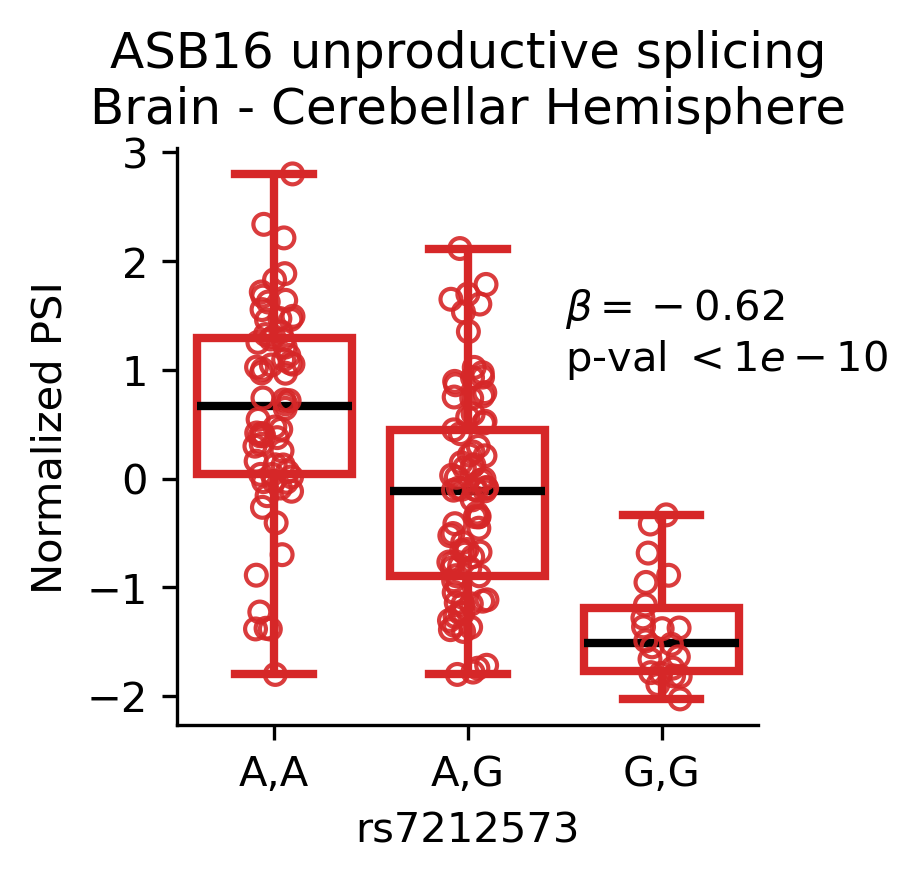

In [44]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm_bch, 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

ax.plot(x, slope * x + intercept, color='red', linestyle='--')

ax.fill_between(x,( slope_90 * np.array(x)) - 0.1, 
                (slope_10 * x) + 0.1, 
                 color='tab:red', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(1.5, 1, r'$\beta = -0.62$' + '\np-val $< 1e-10$')


plt.savefig('../code/plots/fig4_coloc_example_sQTL.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_sQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_sQTL.svg', dpi=300, bbox_inches='tight')

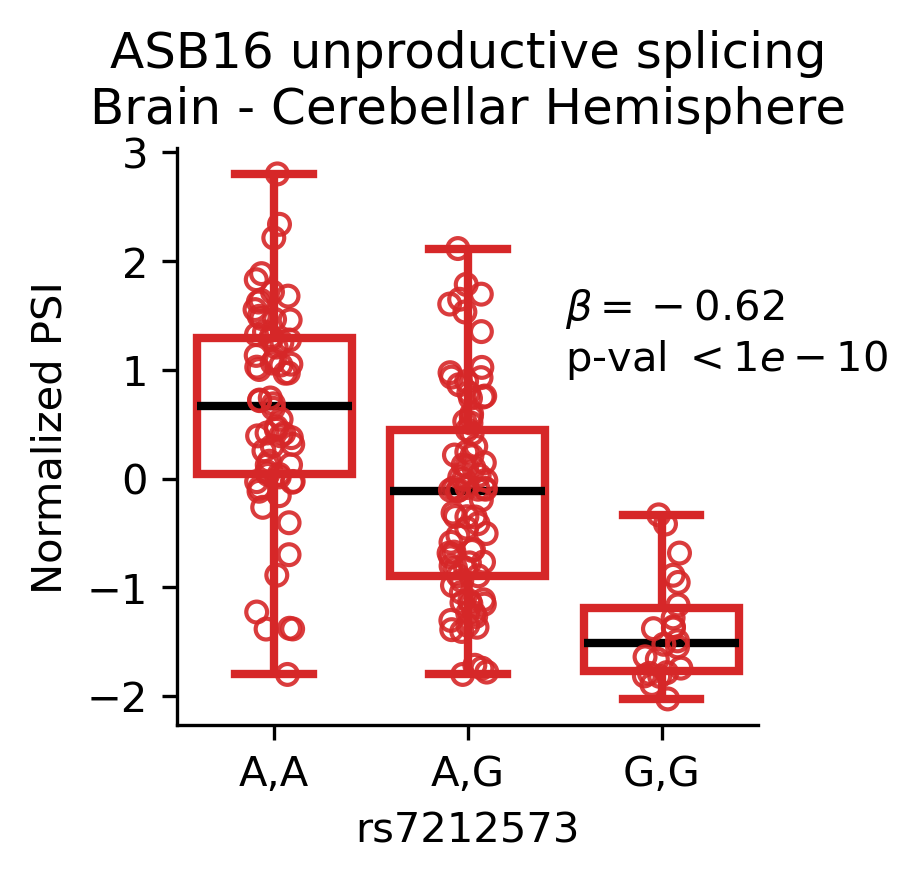

In [45]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df_colored(qqnorm_bch, 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0], color='tab:red')
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch.loc['chr17:44176913'].slope)
slope_se = float(nom_bch.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0.62
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

# ax.plot(x, slope * x + intercept, color='red', linestyle='--')

# ax.fill_between(x,( slope_90 * np.array(x)) + 0.52, 
#                 (slope_10 * x) + 0.72, 
#                  color='tab:red', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(1.5, 1, r'$\beta = -0.62$' + '\np-val $< 1e-10$')


plt.savefig('../code/plots/fig4_coloc_example_sQTL_colored.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_sQTL_colored.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_sQTL_colored.svg', dpi=300, bbox_inches='tight')

In [32]:
np.linspace(0, 2, 100)

array([0.        , 0.02020202, 0.04040404, 0.06060606, 0.08080808,
       0.1010101 , 0.12121212, 0.14141414, 0.16161616, 0.18181818,
       0.2020202 , 0.22222222, 0.24242424, 0.26262626, 0.28282828,
       0.3030303 , 0.32323232, 0.34343434, 0.36363636, 0.38383838,
       0.4040404 , 0.42424242, 0.44444444, 0.46464646, 0.48484848,
       0.50505051, 0.52525253, 0.54545455, 0.56565657, 0.58585859,
       0.60606061, 0.62626263, 0.64646465, 0.66666667, 0.68686869,
       0.70707071, 0.72727273, 0.74747475, 0.76767677, 0.78787879,
       0.80808081, 0.82828283, 0.84848485, 0.86868687, 0.88888889,
       0.90909091, 0.92929293, 0.94949495, 0.96969697, 0.98989899,
       1.01010101, 1.03030303, 1.05050505, 1.07070707, 1.09090909,
       1.11111111, 1.13131313, 1.15151515, 1.17171717, 1.19191919,
       1.21212121, 1.23232323, 1.25252525, 1.27272727, 1.29292929,
       1.31313131, 1.33333333, 1.35353535, 1.37373737, 1.39393939,
       1.41414141, 1.43434343, 1.45454545, 1.47474747, 1.49494

Text(0, 0.5, 'normalized splicing\nBrain Cerebellum')

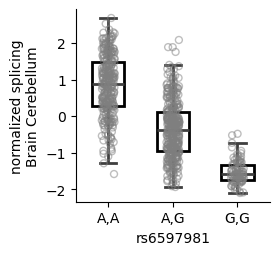

In [351]:
records = get_best_snp_record(vcf_gtex, 'chr17:44176913')

ax = make_boxplot_df(qqnorm_ms, 'chr17:44176940:44177608:clu_30815_+:UP:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBrain Cerebellum')

Text(0, 0.5, 'normalized expression\nSpleen')

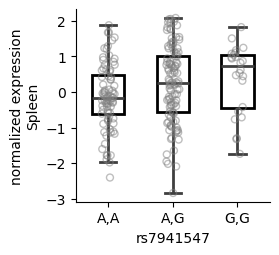

In [336]:
ax = make_boxplot_df(qqnorm_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

In [69]:
nom_bch_e.loc['chr17:44176913'].nom_pval

'6.44861e-08'

In [72]:
nom_bch_e.loc['chr17:44176913'].slope

'0.246418'

In [46]:
ax = make_boxplot_df_colored(qqnorm_bch_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch_e.loc['chr17:44176913'].slope)
slope_se = float(nom_bch_e.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

ax.plot(x, slope * x + intercept, color='red', linestyle='--')

ax.fill_between(x,( slope_90 * np.array(x)) - 0.1, 
                (slope_10 * x) + 0.1, 
                 color='tab:red', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(1.5, -2.8, r'$\beta = 0.25$' + '\np-val $< 1e-7$')



plt.savefig('../code/plots/fig4_coloc_example_eQTL.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_eQTL.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_eQTL.svg', dpi=300, bbox_inches='tight')

SyntaxError: unterminated string literal (detected at line 1) (2017052016.py, line 1)

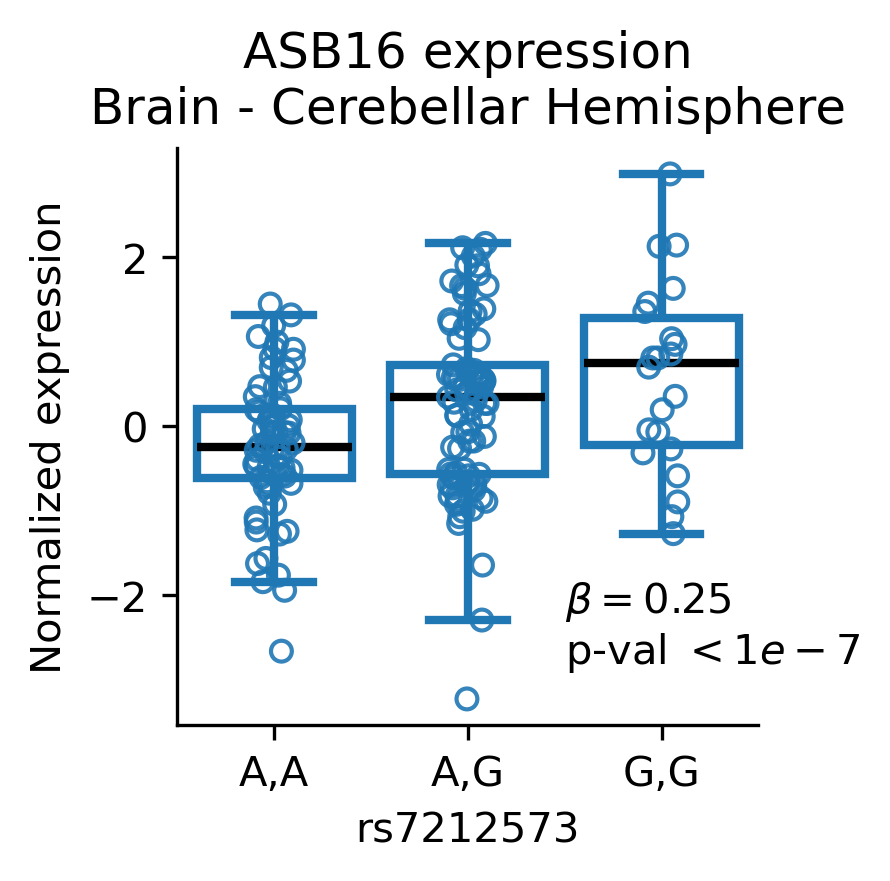

In [48]:
ax = make_boxplot_df_colored(qqnorm_bch_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0], color='tab:blue')
ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

slope = float(nom_bch_e.loc['chr17:44176913'].slope)
slope_se = float(nom_bch_e.loc['chr17:44176913'].slope_se)

n = qqnorm_bch.shape[1]-6  # Number of observations
k = 2   # Number of parameters (e.g., intercept and slope)
confidence_level = 0.95

# Degrees of freedom
df = n - k

# Critical t-value
t_crit = t.ppf((1 + confidence_level) / 2, df)

# Margin of error
margin_of_error = t_crit * slope_se

# Confidence interval
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

intercept = 0
slope_90 = lower_bound
slope_10 = upper_bound

# Plot confidence intervals (optional)

x = np.linspace(0, 2, 100)

# ax.plot(x, slope * x + intercept, color='red', linestyle='--')

# ax.fill_between(x,( slope_90 * np.array(x)) - 0.1, 
#                 (slope_10 * x) + 0.1, 
#                  color='tab:red', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(1.5, -2.8, r'$\beta = 0.25$' + '\np-val $< 1e-7$')



plt.savefig('../code/plots/fig4_coloc_example_eQTL_colored.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_eQTL_colored.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_coloc_example_eQTL_colored.svg', dpi=300, bbox_inches='tight')

Text(0, 0.5, 'normalized expression\nSpleen')

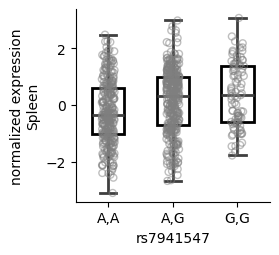

In [353]:
ax = make_boxplot_df(qqnorm_ms_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', records[0])
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized expression\nSpleen')

In [334]:
qqnorm_e.loc[qqnorm_e.pid.apply(lambda x: 'ENSG00000161664' in x)]

,#Chr,start,end,pid,gid,strand,GTEX-111FC,GTEX-1128S,GTEX-117XS,GTEX-1192X,...,GTEX-ZAB4,GTEX-ZAJG,GTEX-ZAK1,GTEX-ZDXO,GTEX-ZF28,GTEX-ZUA1,GTEX-ZVT3,GTEX-ZYFD,GTEX-ZYY3,GTEX-ZZPT
pid,,,,,,,,,,,,,,,,,,,,,
ENSG00000161664.7:chr17_43671083_N_N_Dupuytrens_disease,chr17,43171083,44171083,ENSG00000161664.7:chr17_43671083_N_N_Dupuytren...,ENSG00000161664,+,0.06508,-1.64639,-0.54785,-1.32077,...,1.93207,-0.58716,0.61534,0.71699,-2.01992,1.87036,-0.22373,-0.74416,-0.22818,-1.13865
ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder,chr17,43614525,44614525,ENSG00000161664.7:chr17_44114525_N_N_bipolar_d...,ENSG00000161664,+,0.06508,-1.64639,-0.54785,-1.32077,...,1.93207,-0.58716,0.61534,0.71699,-2.01992,1.87036,-0.22373,-0.74416,-0.22818,-1.13865
ENSG00000161664.7:chr17_44201548_N_N_Visceral_adipose_tissue_measurement,chr17,43701548,44701548,ENSG00000161664.7:chr17_44201548_N_N_Visceral_...,ENSG00000161664,+,0.06508,-1.64639,-0.54785,-1.32077,...,1.93207,-0.58716,0.61534,0.71699,-2.01992,1.87036,-0.22373,-0.74416,-0.22818,-1.13865


In [357]:
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')


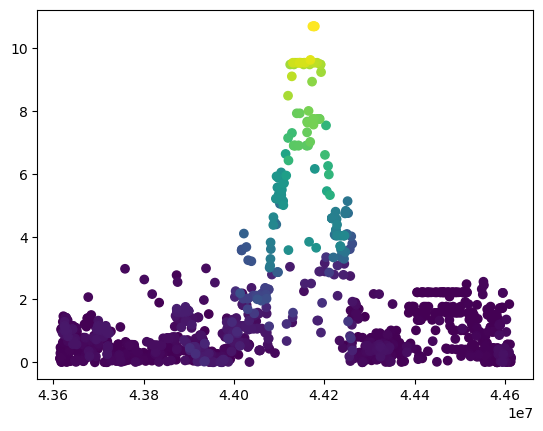

In [365]:
pos = [int(x.split(':')[1]) for x in scatter_df.index]
plt.scatter(pos, np.array(scatter_df.sQTL), c=scatter_df.r2)

In [377]:
annot.loc[annot.gene_id == 'ENSG00000161664']

,#chrom,start,end,gene_id,gene_name,strand,gene_type,transcript_id,transcript_type
28,chr17,44170447,44170537,ENSG00000161664,ASB16,+,protein_coding,ENST00000591700,protein_coding
29,chr17,44170704,44171090,ENSG00000161664,ASB16,+,protein_coding,ENST00000293414,protein_coding
30,chr17,44170724,44171090,ENSG00000161664,ASB16,+,protein_coding,ENST00000589618,nonsense_mediated_decay
31,chr17,44170847,44171090,ENSG00000161664,ASB16,+,protein_coding,ENST00000591700,protein_coding
32,chr17,44172046,44172313,ENSG00000161664,ASB16,+,protein_coding,ENST00000293414,protein_coding
33,chr17,44172046,44172313,ENSG00000161664,ASB16,+,protein_coding,ENST00000589618,nonsense_mediated_decay
34,chr17,44172046,44172209,ENSG00000161664,ASB16,+,protein_coding,ENST00000591700,protein_coding
43,chr17,44176738,44176940,ENSG00000161664,ASB16,+,protein_coding,ENST00000589618,nonsense_mediated_decay
44,chr17,44176738,44177230,ENSG00000161664,ASB16,+,protein_coding,ENST00000293414,protein_coding
45,chr17,44177609,44177722,ENSG00000161664,ASB16,+,protein_coding,ENST00000293414,protein_coding


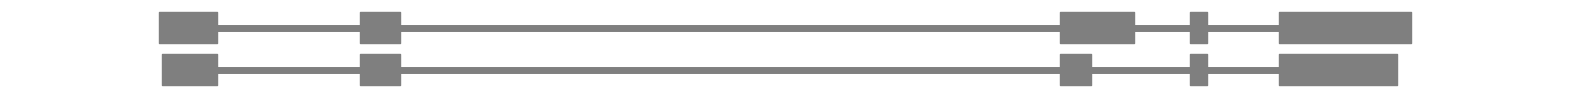

In [11]:
plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000293414', 'ENST00000589618'])], 'ENSG00000161664', 
                         colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None)

plt.savefig('../code/plots/fig4_ASB16.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_ASB16.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_ASB16.svg', dpi=300, bbox_inches='tight')